In [262]:
from sqlalchemy.orm import sessionmaker
from PanoDB_link import engine,CommandLog
import pandas as pd
from datetime import datetime, timezone
import pytz
import matplotlib.dates as mdates
import json

paris = pytz.timezone("Europe/Paris")

mois={
    1 :"janvier",
    2 :"février",
    3 :"mars",
    4 :"avril",
    5 :"mai",
    6 :"juin",
    7 :"juillet",
    8 :"août",
    9 :"septembre",
    10 :"octobre",
    11 :"novembre",
    12 :"décembre",   
}

import matplotlib.pyplot as plt


In [247]:
# Avec SQLAlchemy engine
logs = pd.read_sql("SELECT * FROM command_logs", con=engine)
logs['executed_at'] = logs['executed_at'].dt.tz_localize('UTC').dt.tz_convert('Europe/Paris')
logs.tail()


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
3840,3841,2025-09-23 18:16:01+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
3841,3842,2025-09-23 18:16:19+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""classe"": ""osamodas""}"
3842,3843,2025-09-23 19:08:23+02:00,9.385262e+17,adzm95,1.413112e+18,Les pichons bagarreur,1.413178e+18,〖🐢〗carapace-de-maitre-pichon,stuff,"{""classe"": ""iop"", ""element"": ""terre air""}"
3843,3844,2025-09-23 19:53:41+02:00,7.391242e+17,yaston.rozay,1.344711e+18,Dofus Touls,1.344712e+18,💬│chat-metapano,stuff,"{""element"": ""dopou""}"
3844,3845,2025-09-23 19:57:28+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""classe"": ""enutrof"", ""element"": ""terre feu""}"


In [248]:
logs_users=logs[logs["user_name"]!="warp_is_fine"]
logs_users

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
126,127,2025-02-06 09:51:00+01:00,8.476086e+17,blusterdofus,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""air""}"
127,128,2025-02-06 18:49:51+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau""}"
128,129,2025-02-06 18:50:24+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau docrit""}"
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
...,...,...,...,...,...,...,...,...,...,...
3828,3829,2025-09-23 14:00:39+02:00,2.760975e+17,nicote2porc,1.344711e+18,Dofus Touls,1.344712e+18,💬│chat-metapano,stuff,"{""pa_min"": 12, ""element"": ""terre air""}"
3834,3835,2025-09-23 14:41:31+02:00,5.035278e+17,icaresx,1.226156e+18,Nouveau Règne [NRV],1.278476e+18,👑▪optimisation-stuff,stuff,"{""element"": ""Eau terre""}"
3835,3836,2025-09-23 14:51:32+02:00,5.035278e+17,icaresx,1.226156e+18,Nouveau Règne [NRV],1.278476e+18,👑▪optimisation-stuff,stuff,"{""element"": ""Terre""}"
3842,3843,2025-09-23 19:08:23+02:00,9.385262e+17,adzm95,1.413112e+18,Les pichons bagarreur,1.413178e+18,〖🐢〗carapace-de-maitre-pichon,stuff,"{""classe"": ""iop"", ""element"": ""terre air""}"


In [249]:
logs_warp=logs[logs["user_name"]=="warp_is_fine"]
logs_warp

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
0,1,2025-09-22 23:53:41+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
1,2,2025-09-22 23:55:28+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test""}"
2,3,2025-09-22 23:58:00+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test2""}"
3,4,2025-02-01 23:13:43+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
4,5,2025-02-01 23:15:11+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
...,...,...,...,...,...,...,...,...,...,...
3838,3839,2025-09-23 16:23:44+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
3839,3840,2025-09-23 17:02:41+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
3840,3841,2025-09-23 18:16:01+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
3841,3842,2025-09-23 18:16:19+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""classe"": ""osamodas""}"


In [250]:
nb_logs=len(logs)
nb_logs_users=len(logs_users)
nb_logs_guild_id_null=len(logs[logs["guild_id"].isna()])
nb_logs_guild_id_null_unique=len(logs[logs["guild_id"].isna()]["guild_name"].unique())
nb_guild_names=len(logs["guild_name"].unique())
nb_logs_channel_id_null=len(logs[logs["channel_id"].isna()])
nb_logs_channel_id_null_unique=len(logs[logs["channel_id"].isna()]["channel_name"].unique())
nb_channel_names=len(logs["channel_name"].unique())
nb_logs_user_id_null=len(logs[logs["user_id"].isna()])
nb_logs_user_id_null_unique=len(logs[logs["user_id"].isna()]["user_name"].unique())
nb_user_names=len(logs["user_name"].unique())

print(f"Nombre de logs : {nb_logs}")
print(f"Nombre de logs sans warp : {nb_logs_users}")
print(f"Nombre de guilds : {nb_guild_names}")
print(f"Nombre de channels : {nb_channel_names}")
print(f"Nombre de users : {nb_user_names}")
print(f"Nombre de logs avec guild_id NULL : {nb_logs_guild_id_null} pour {nb_logs_guild_id_null_unique} uniques guild_name")
print(f"Nombre de logs avec channel_id NULL : {nb_logs_channel_id_null} pour {nb_logs_channel_id_null_unique} uniques channel_name")
print(f"Nombre de logs avec user_id NULL : {nb_logs_user_id_null} pour {nb_logs_user_id_null_unique} uniques user_name")


Nombre de logs : 3845
Nombre de logs sans warp : 2621
Nombre de guilds : 79
Nombre de channels : 121
Nombre de users : 445
Nombre de logs avec guild_id NULL : 193 pour 17 uniques guild_name
Nombre de logs avec channel_id NULL : 359 pour 39 uniques channel_name
Nombre de logs avec user_id NULL : 315 pour 104 uniques user_name


# commandes à un temps précis

In [251]:
logs[logs["executed_at"] > paris.localize(datetime(2025, 9, 22, 0, 0, 1))][logs["executed_at"] > paris.localize(datetime(2025, 9, 23, 0, 0, 1))].sort_values(by="executed_at")

C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\1009947779.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  logs[logs["executed_at"] > paris.localize(datetime(2025, 9, 22, 0, 0, 1))][logs["executed_at"] > paris.localize(datetime(2025, 9, 23, 0, 0, 1))].sort_values(by="executed_at")


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
3808,3809,2025-09-23 00:44:18+02:00,6.099900e+17,to27.,1.344711e+18,Dofus Touls,1.344711e+18,💬│chat-general,stuff,"{""element"": ""eau feu air""}"
3809,3810,2025-09-23 00:44:45+02:00,6.099900e+17,to27.,1.344711e+18,Dofus Touls,1.344711e+18,💬│chat-general,stuff,"{""element"": ""eau feu terre""}"
3810,3811,2025-09-23 01:01:00+02:00,9.689332e+17,zabuzay,1.279805e+18,Zerbaax,1.404211e+18,bot-stuff,stuff,"{""element"": ""terre feu""}"
3811,3812,2025-09-23 01:26:01+02:00,4.866521e+17,ogthem,8.098754e+17,! 𝗞𝗚 Latif's server Privet,8.098754e+17,general,stuff,"{""classe"": ""sram"", ""element"": ""feu""}"
3812,3813,2025-09-23 01:27:10+02:00,4.866521e+17,ogthem,8.098754e+17,! 𝗞𝗚 Latif's server Privet,8.098754e+17,general,bibliotheques,{}
3813,3814,2025-09-23 01:27:26+02:00,4.866521e+17,ogthem,8.098754e+17,! 𝗞𝗚 Latif's server Privet,8.098754e+17,general,stuff,"{""classe"": ""sram"", ""element"": ""terre""}"
3814,3815,2025-09-23 01:31:46+02:00,4.866521e+17,ogthem,1.213699e+18,[LIFE] Alliance,1.343900e+18,sram,stuff,"{""classe"": ""sram"", ""element"": ""air""}"
3815,3816,2025-09-23 01:32:00+02:00,4.866521e+17,ogthem,1.213699e+18,[LIFE] Alliance,1.343900e+18,sram,stuff,"{""classe"": ""sram"", ""element"": ""feu""}"
3816,3817,2025-09-23 01:32:14+02:00,4.866521e+17,ogthem,1.213699e+18,[LIFE] Alliance,1.343900e+18,sram,stuff,"{""classe"": ""sram"", ""element"": ""terre""}"
3817,3818,2025-09-23 01:32:45+02:00,4.866521e+17,ogthem,8.098754e+17,! 𝗞𝗚 Latif's server Privet,8.098754e+17,general,stuff,"{""classe"": ""sram""}"


# commandes d'un serveur précis

In [252]:
logs_users.loc[logs_users["guild_id"]==933448236939743360.0]
# logs_users.loc[logs_users["guild_name"]=="La Secte"]

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
134,135,2025-02-09 10:21:48+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""xelor""}"
139,140,2025-02-13 17:58:41+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""feu""}"
140,141,2025-02-13 17:59:05+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air""}"
...,...,...,...,...,...,...,...,...,...,...
3767,3768,2025-09-21 01:00:01+02:00,5.598084e+17,edjyz.999,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""dopou""}"
3768,3769,2025-09-21 05:26:39+02:00,2.631326e+17,alkoolik,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
3776,3777,2025-09-21 18:52:13+02:00,2.349671e+17,goodrilaz,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
3784,3785,2025-09-22 01:48:58+02:00,2.919459e+17,cedp,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""feu eau""}"


# commandes d'un utilisateur précis

In [253]:
user="warp_is_fine"
logs.loc[logs["user_name"]==user]

# userid=357960636509978624
# logs.loc[logs["user_id"]==userid]


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
0,1,2025-09-22 23:53:41+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
1,2,2025-09-22 23:55:28+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test""}"
2,3,2025-09-22 23:58:00+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test2""}"
3,4,2025-02-01 23:13:43+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
4,5,2025-02-01 23:15:11+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
...,...,...,...,...,...,...,...,...,...,...
3838,3839,2025-09-23 16:23:44+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
3839,3840,2025-09-23 17:02:41+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
3840,3841,2025-09-23 18:16:01+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
3841,3842,2025-09-23 18:16:19+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""classe"": ""osamodas""}"


# utilisation des commandes

## utilisation des commandes utilisateurs

C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\1125364631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\1125364631.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_users['week'] = logs_users['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\1125364631.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

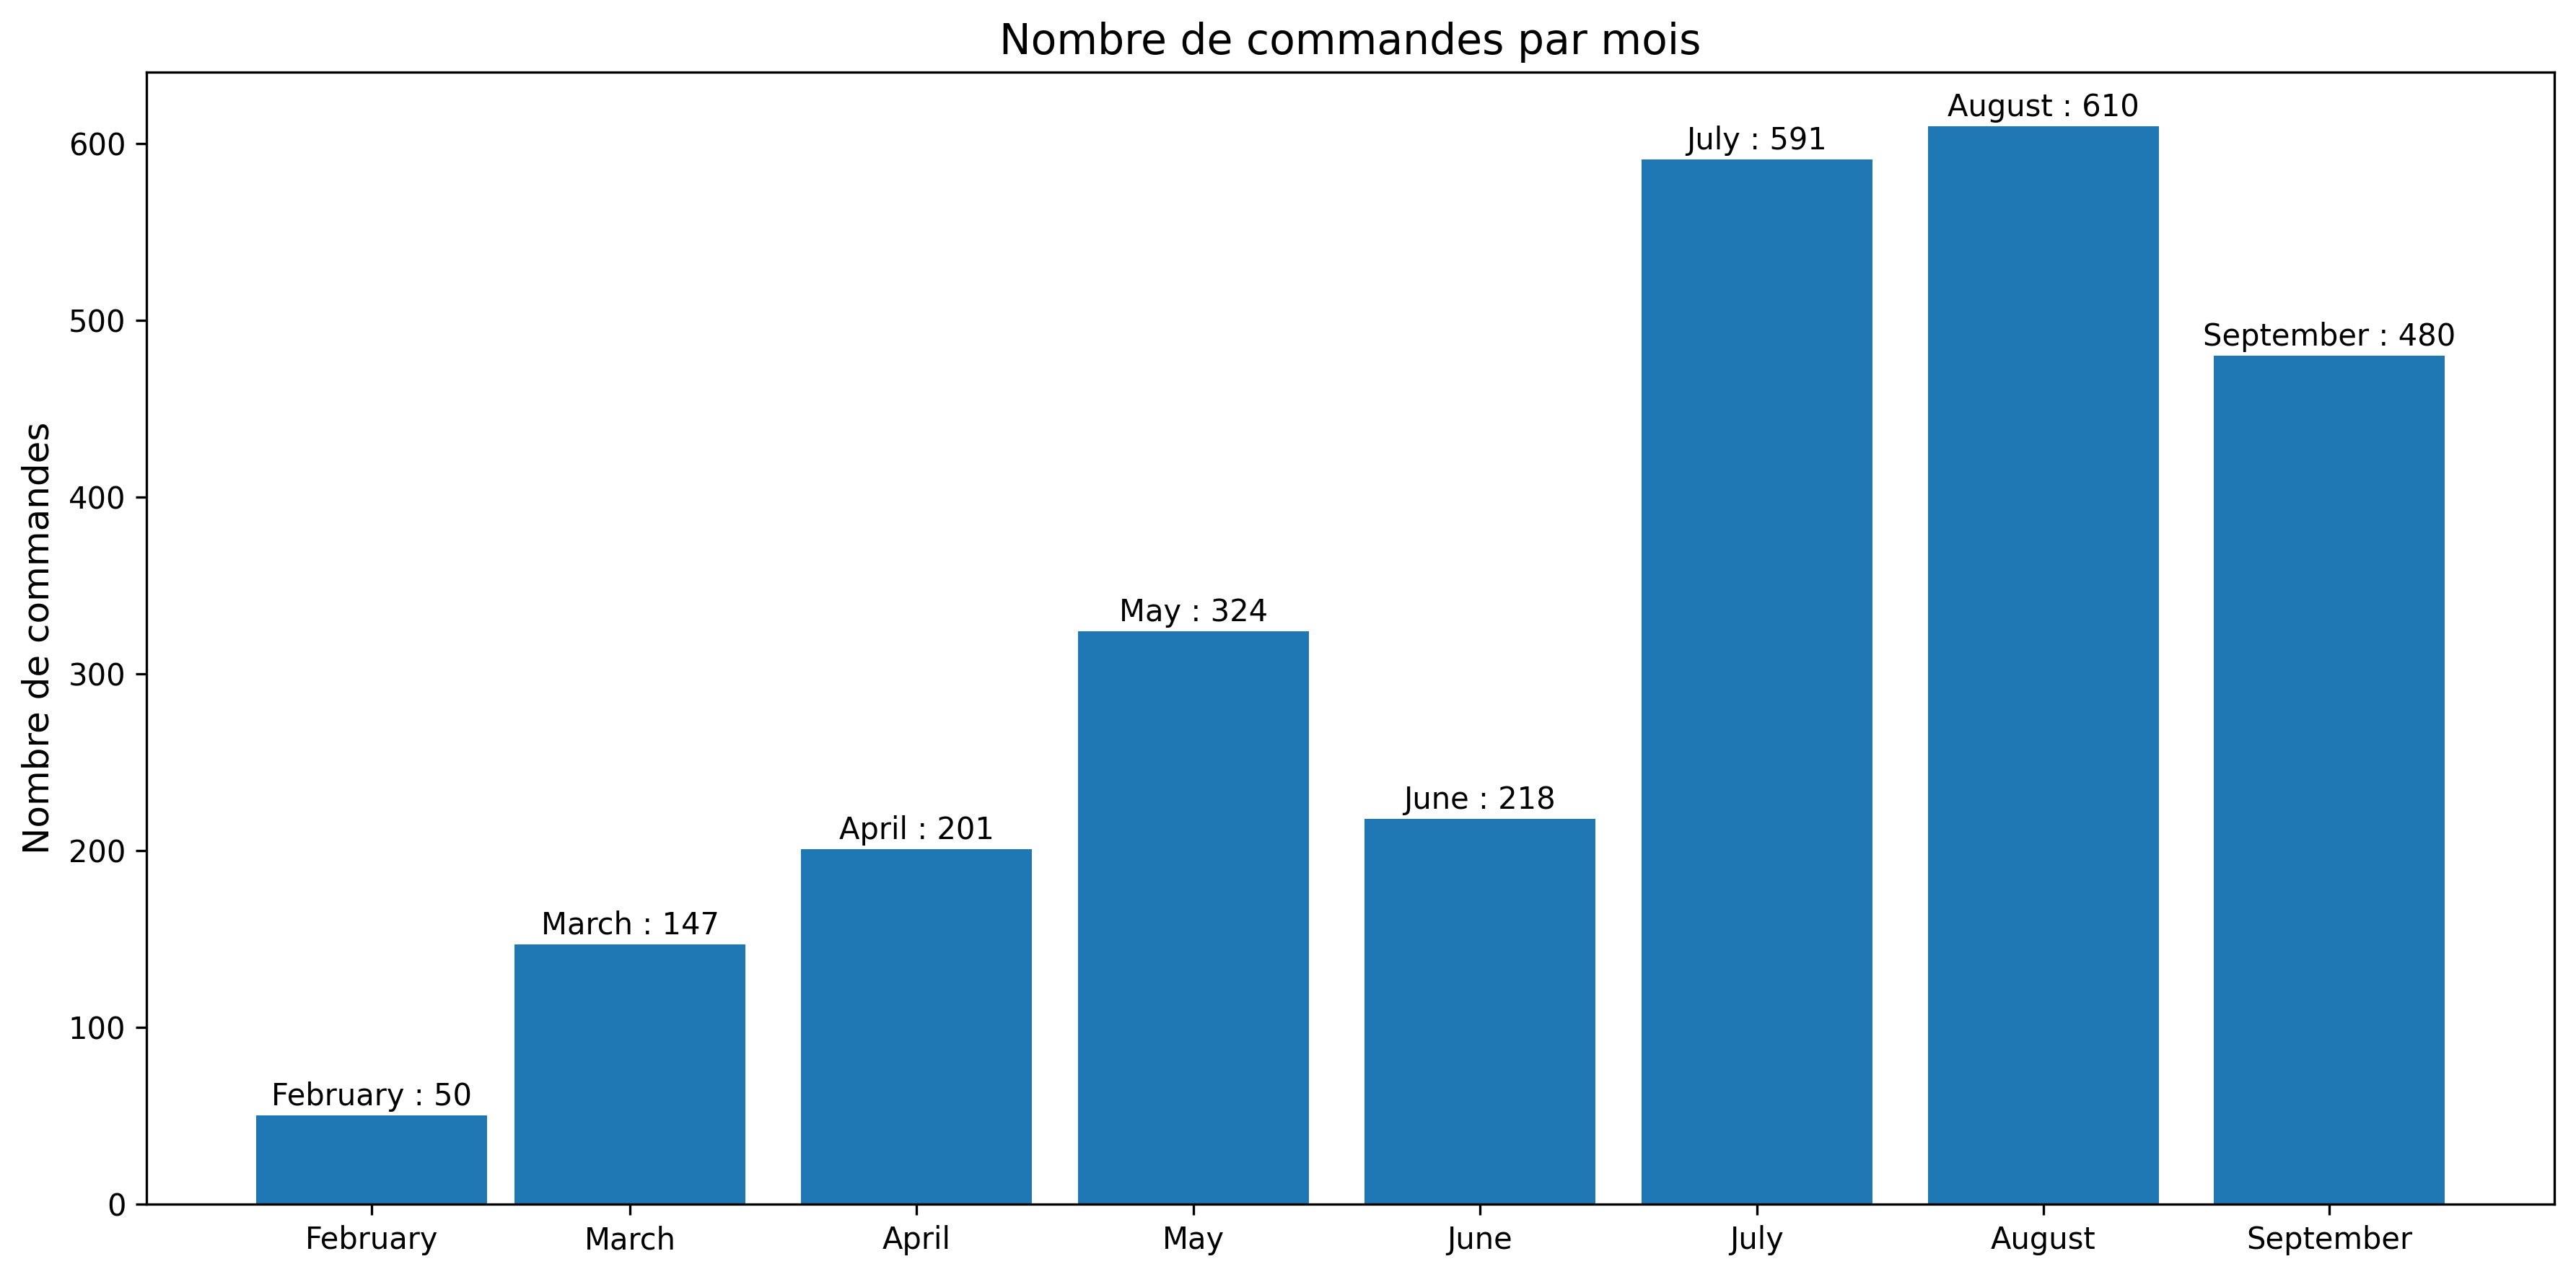

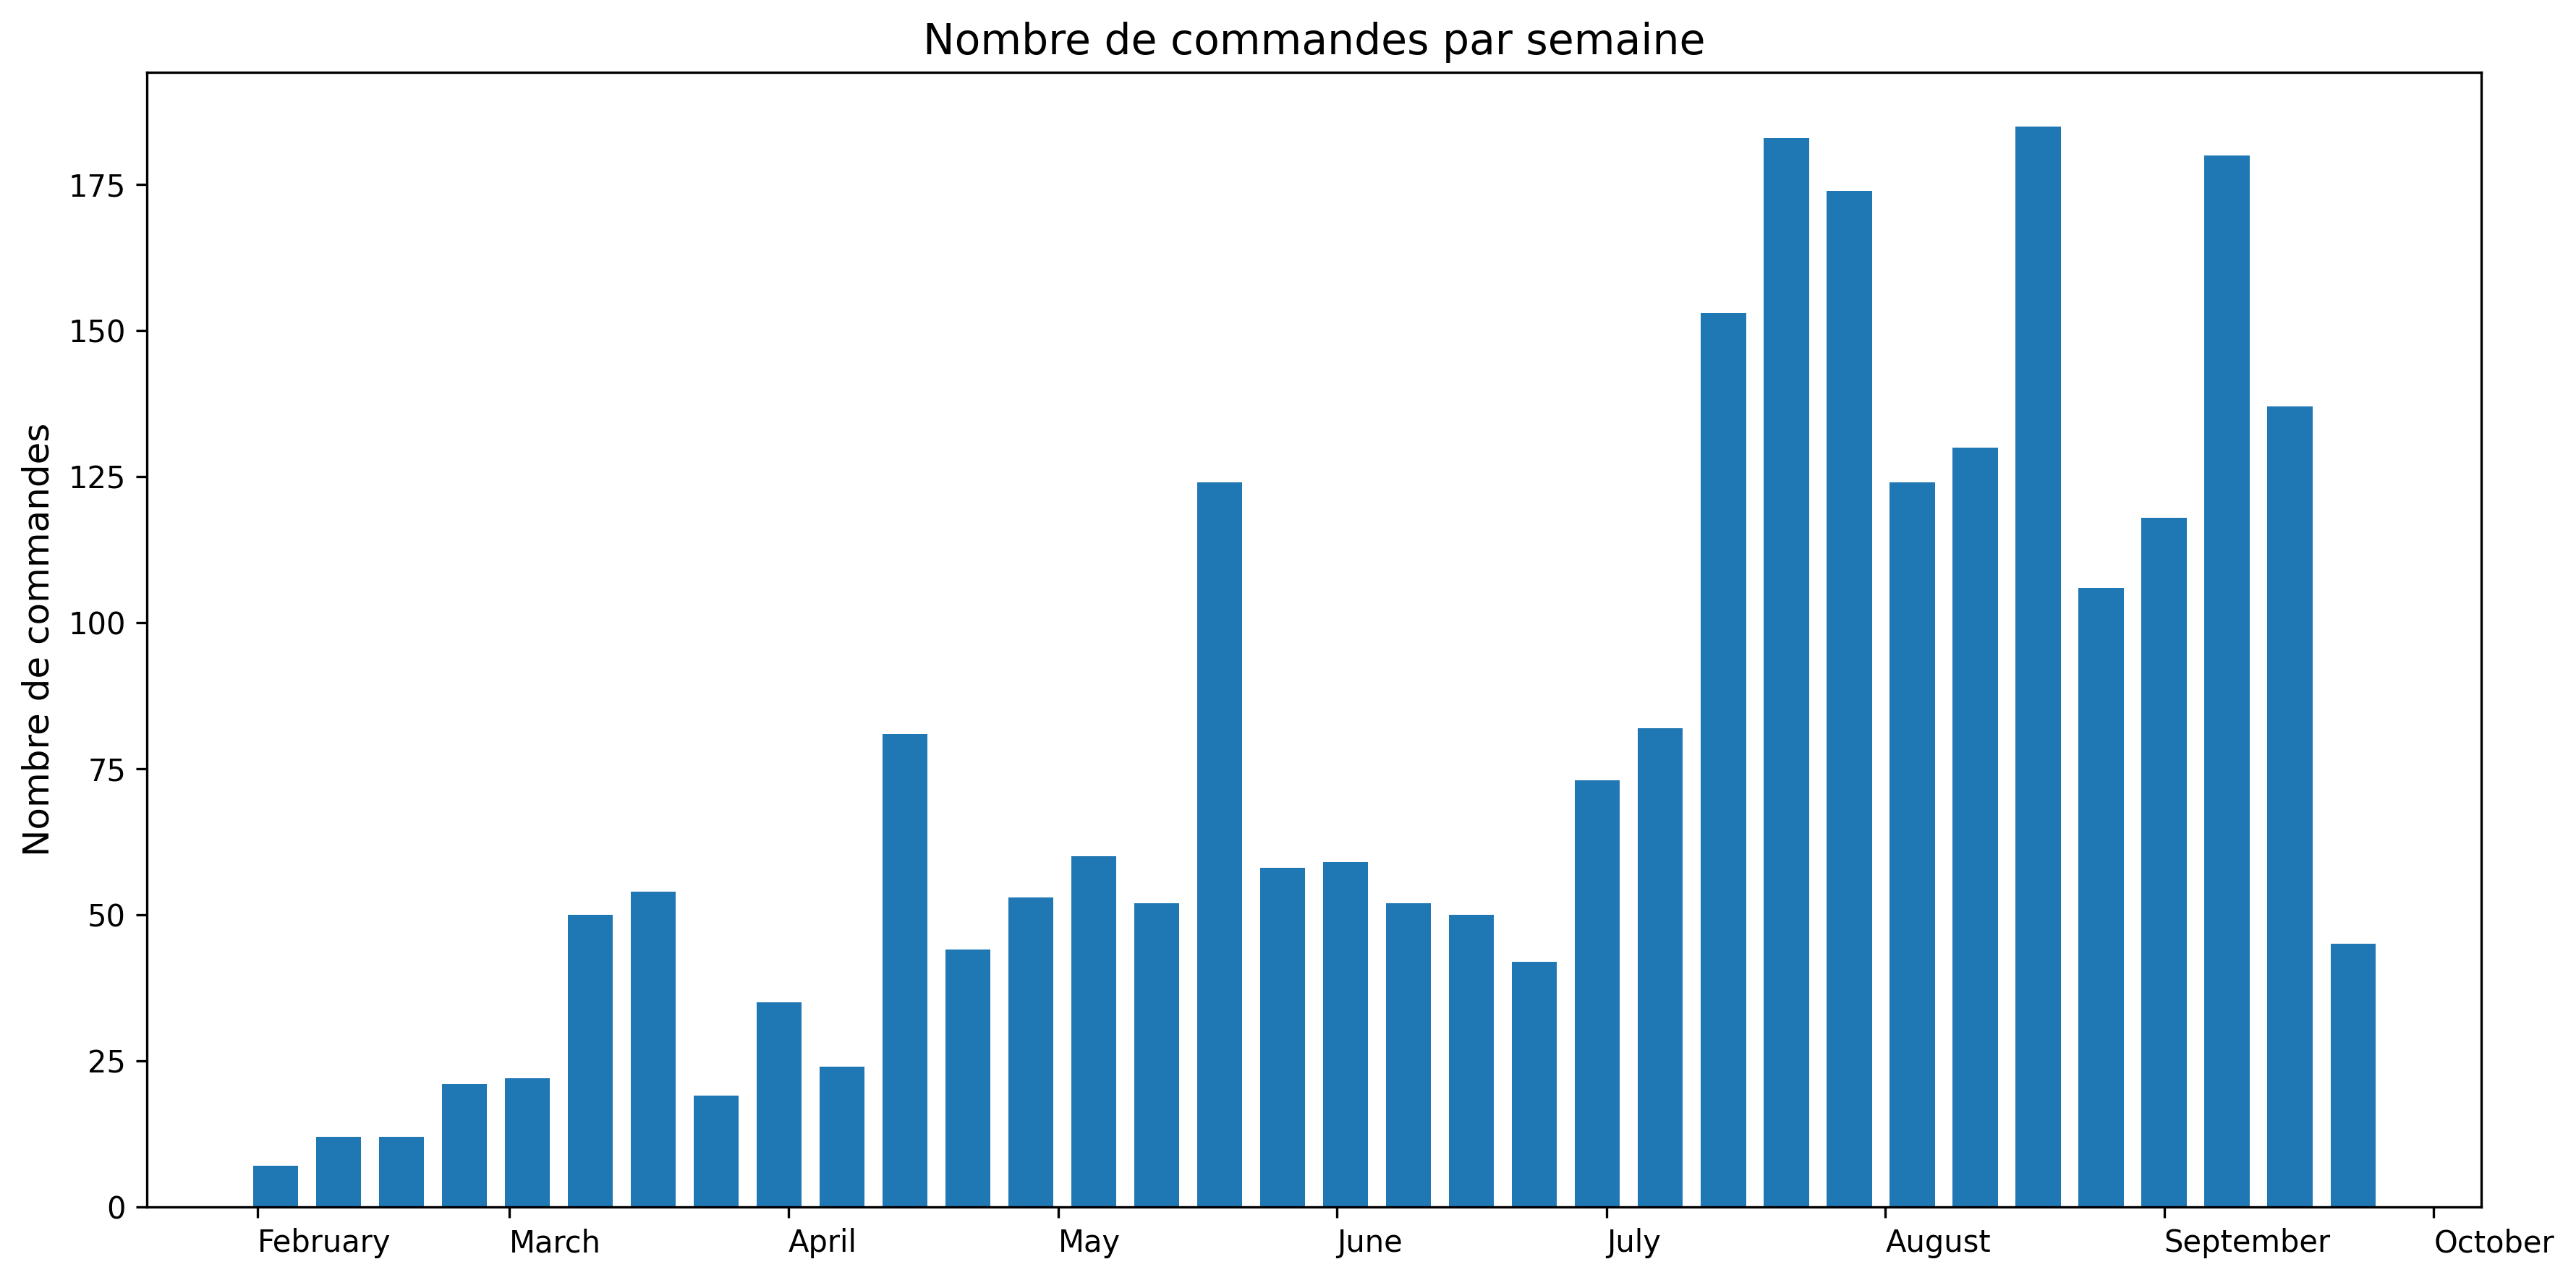

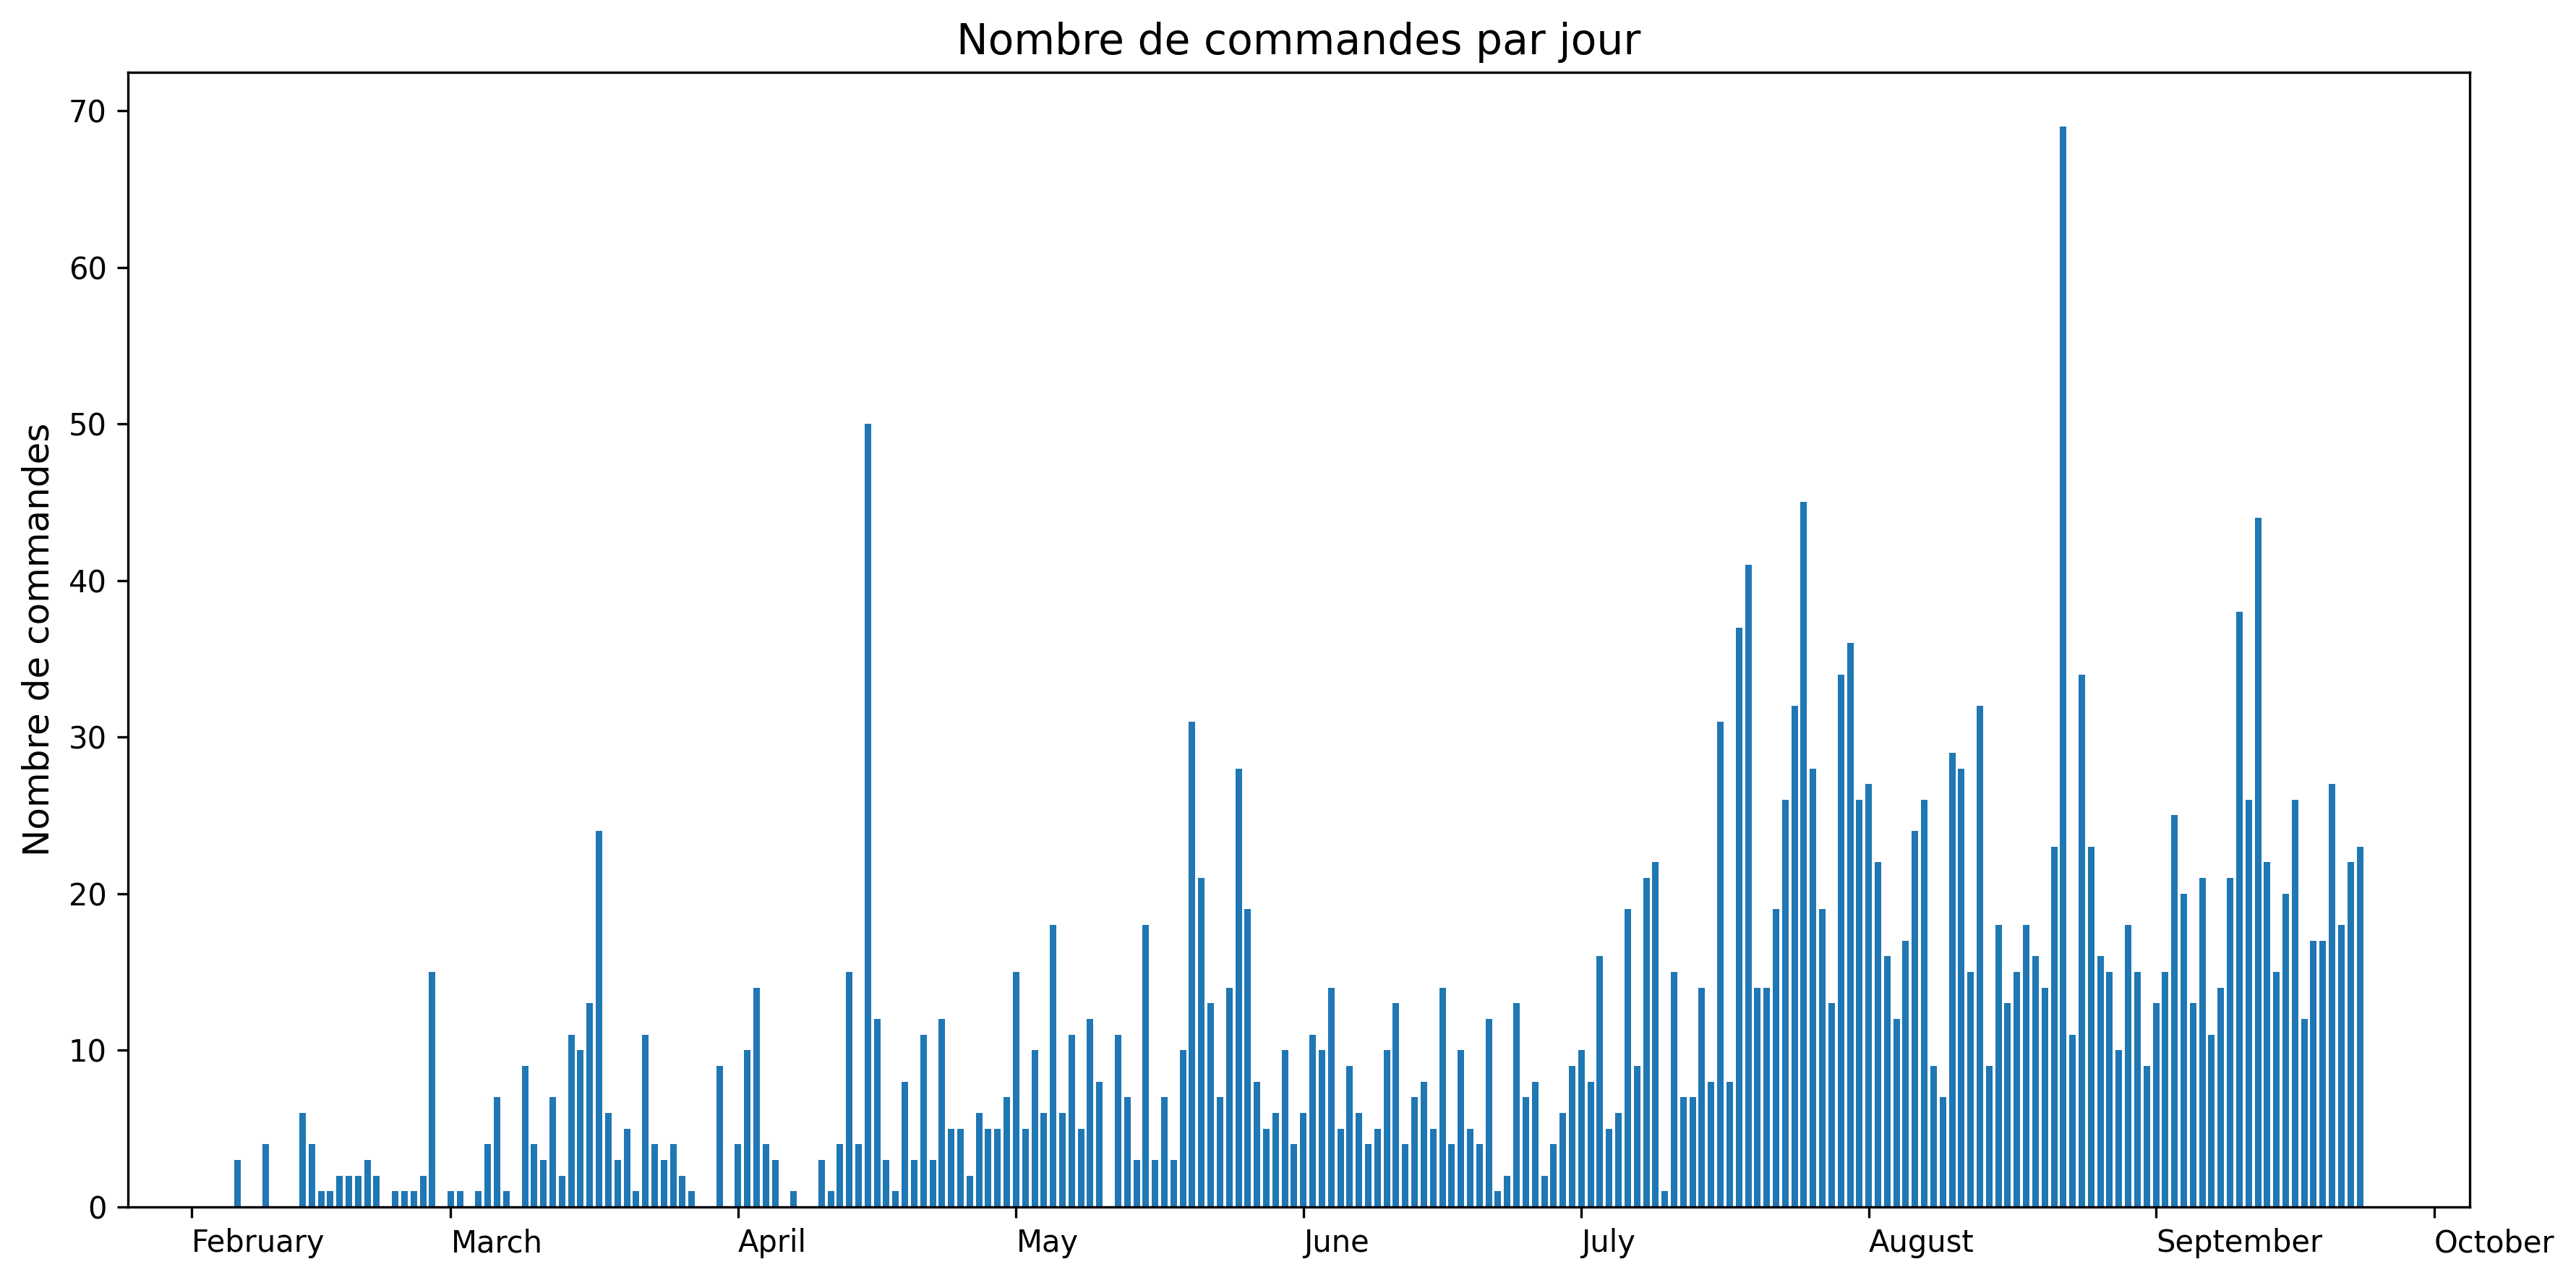

In [254]:
# Assurer que executed_at est bien un datetime
logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])

# --- Par jour ---
logs_per_day = logs_users.groupby(logs_users['executed_at'].dt.date).size()

# --- Par semaine ---
logs_users['week'] = logs_users['executed_at'].dt.to_period('W')
logs_per_week = logs_users.groupby('week').size()

# --- Par mois ---
logs_users['month'] = logs_users['executed_at'].dt.to_period('M')
logs_per_month = logs_users.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)



# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
###ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()




## utilisation des commandes tout le monde

C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\4148849298.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs['week'] = logs['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\4148849298.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs['month'] = logs['executed_at'].dt.to_period('M')


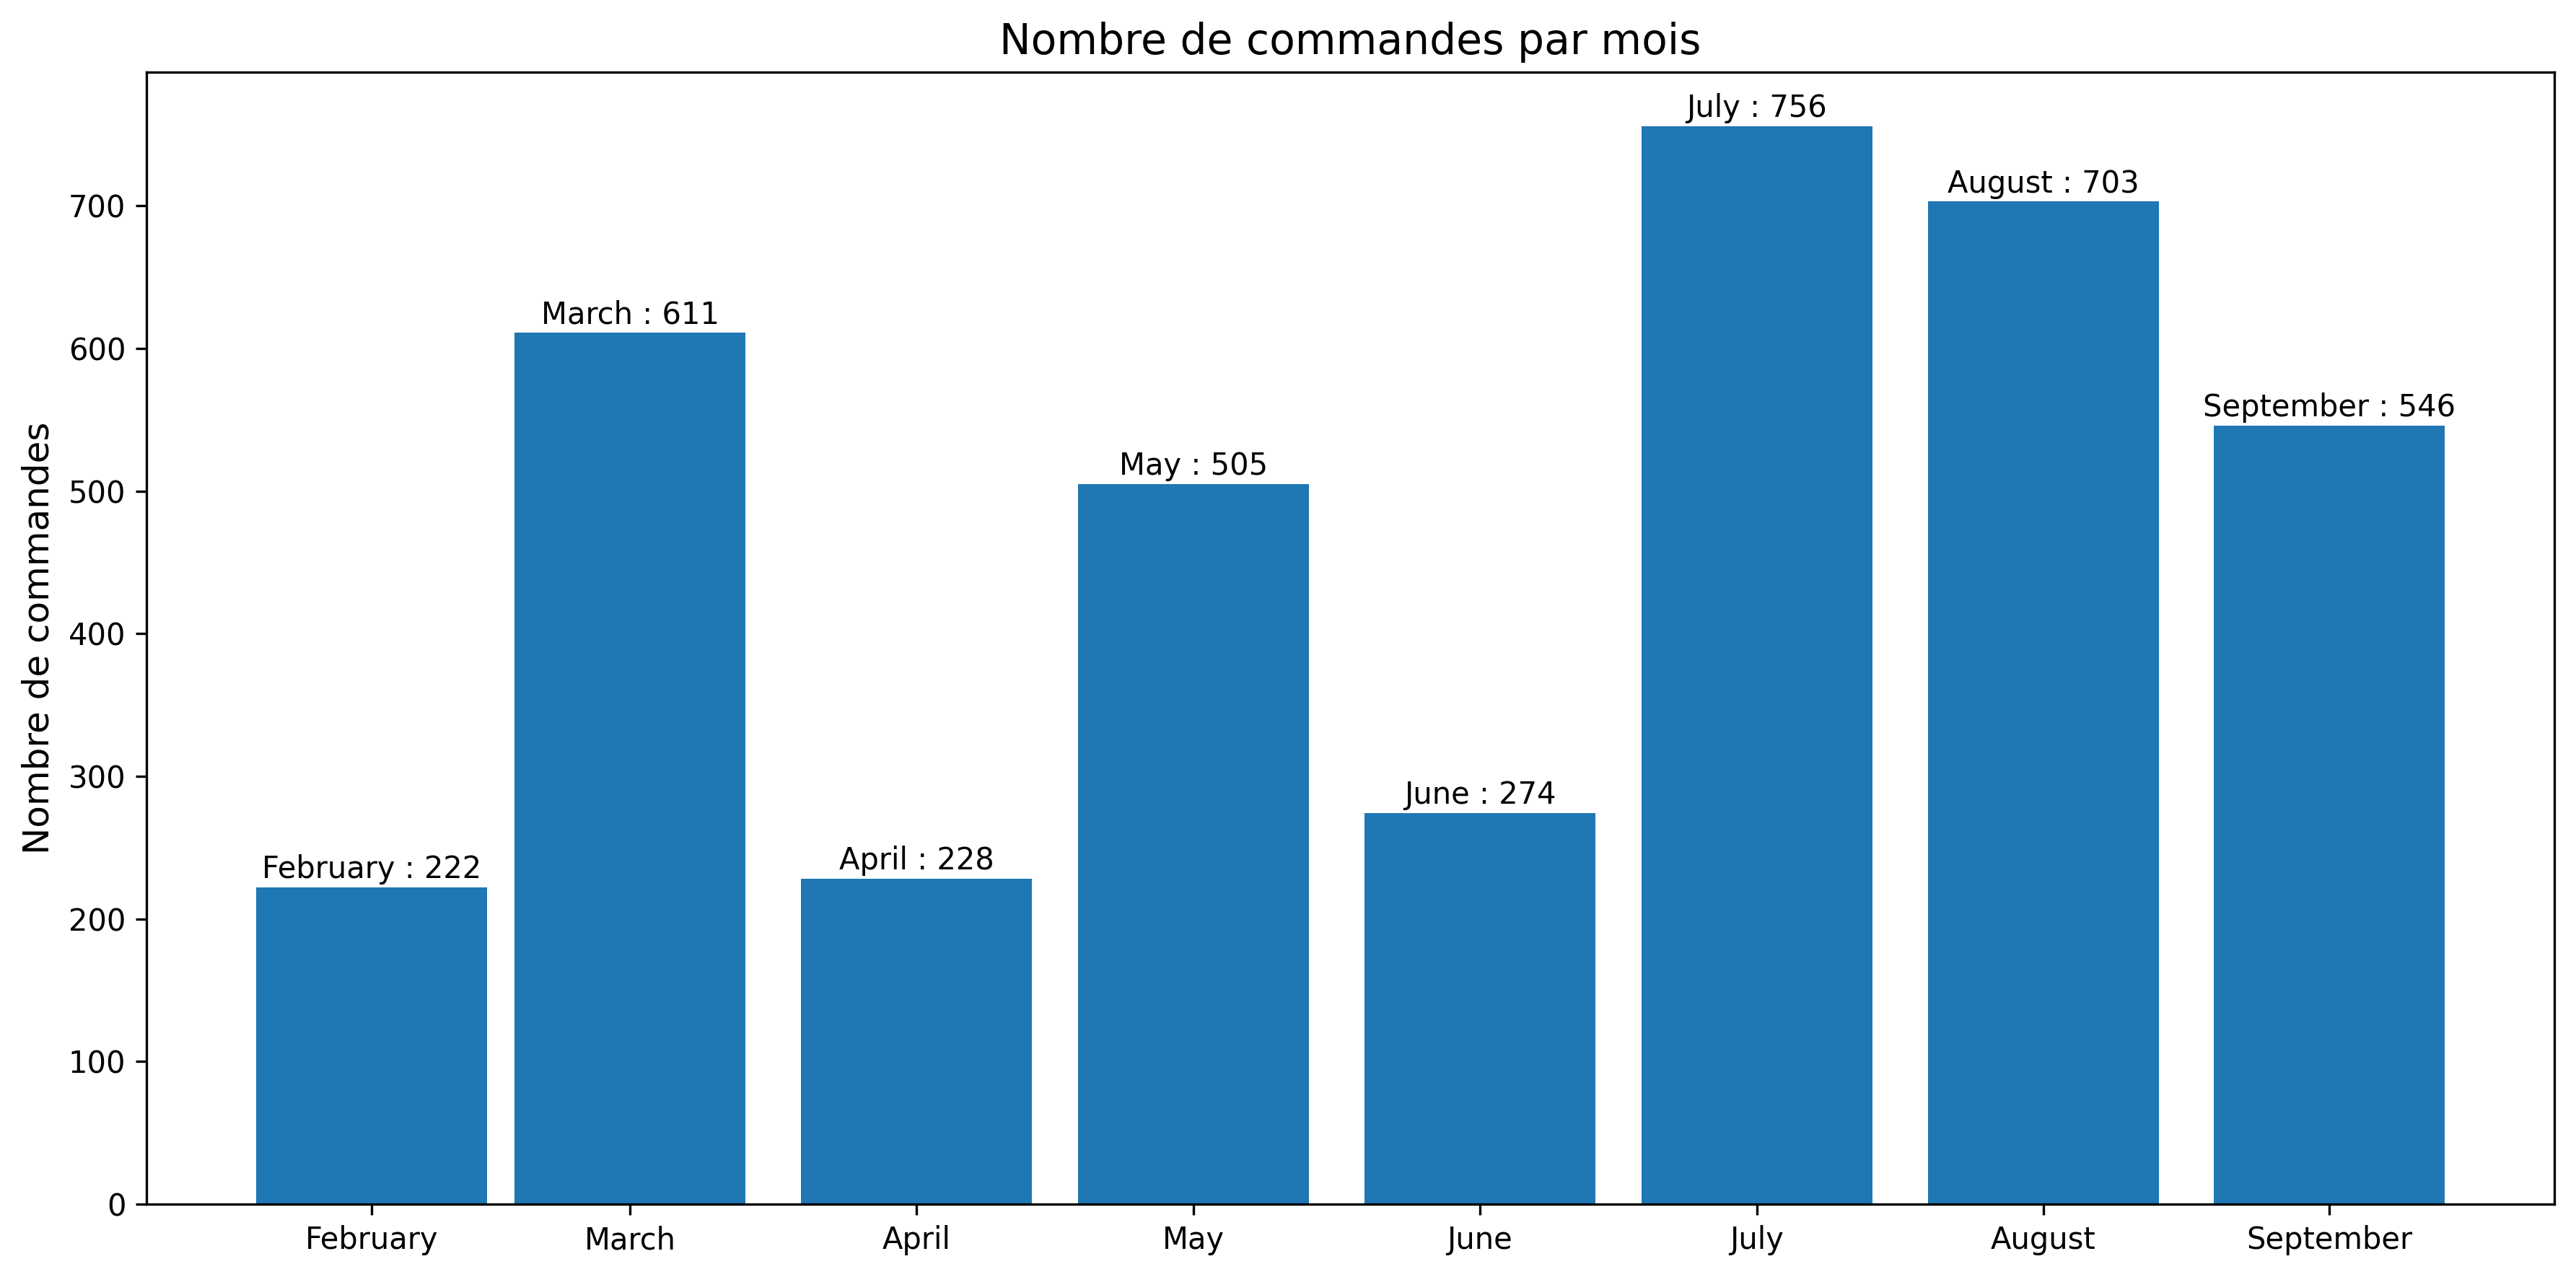

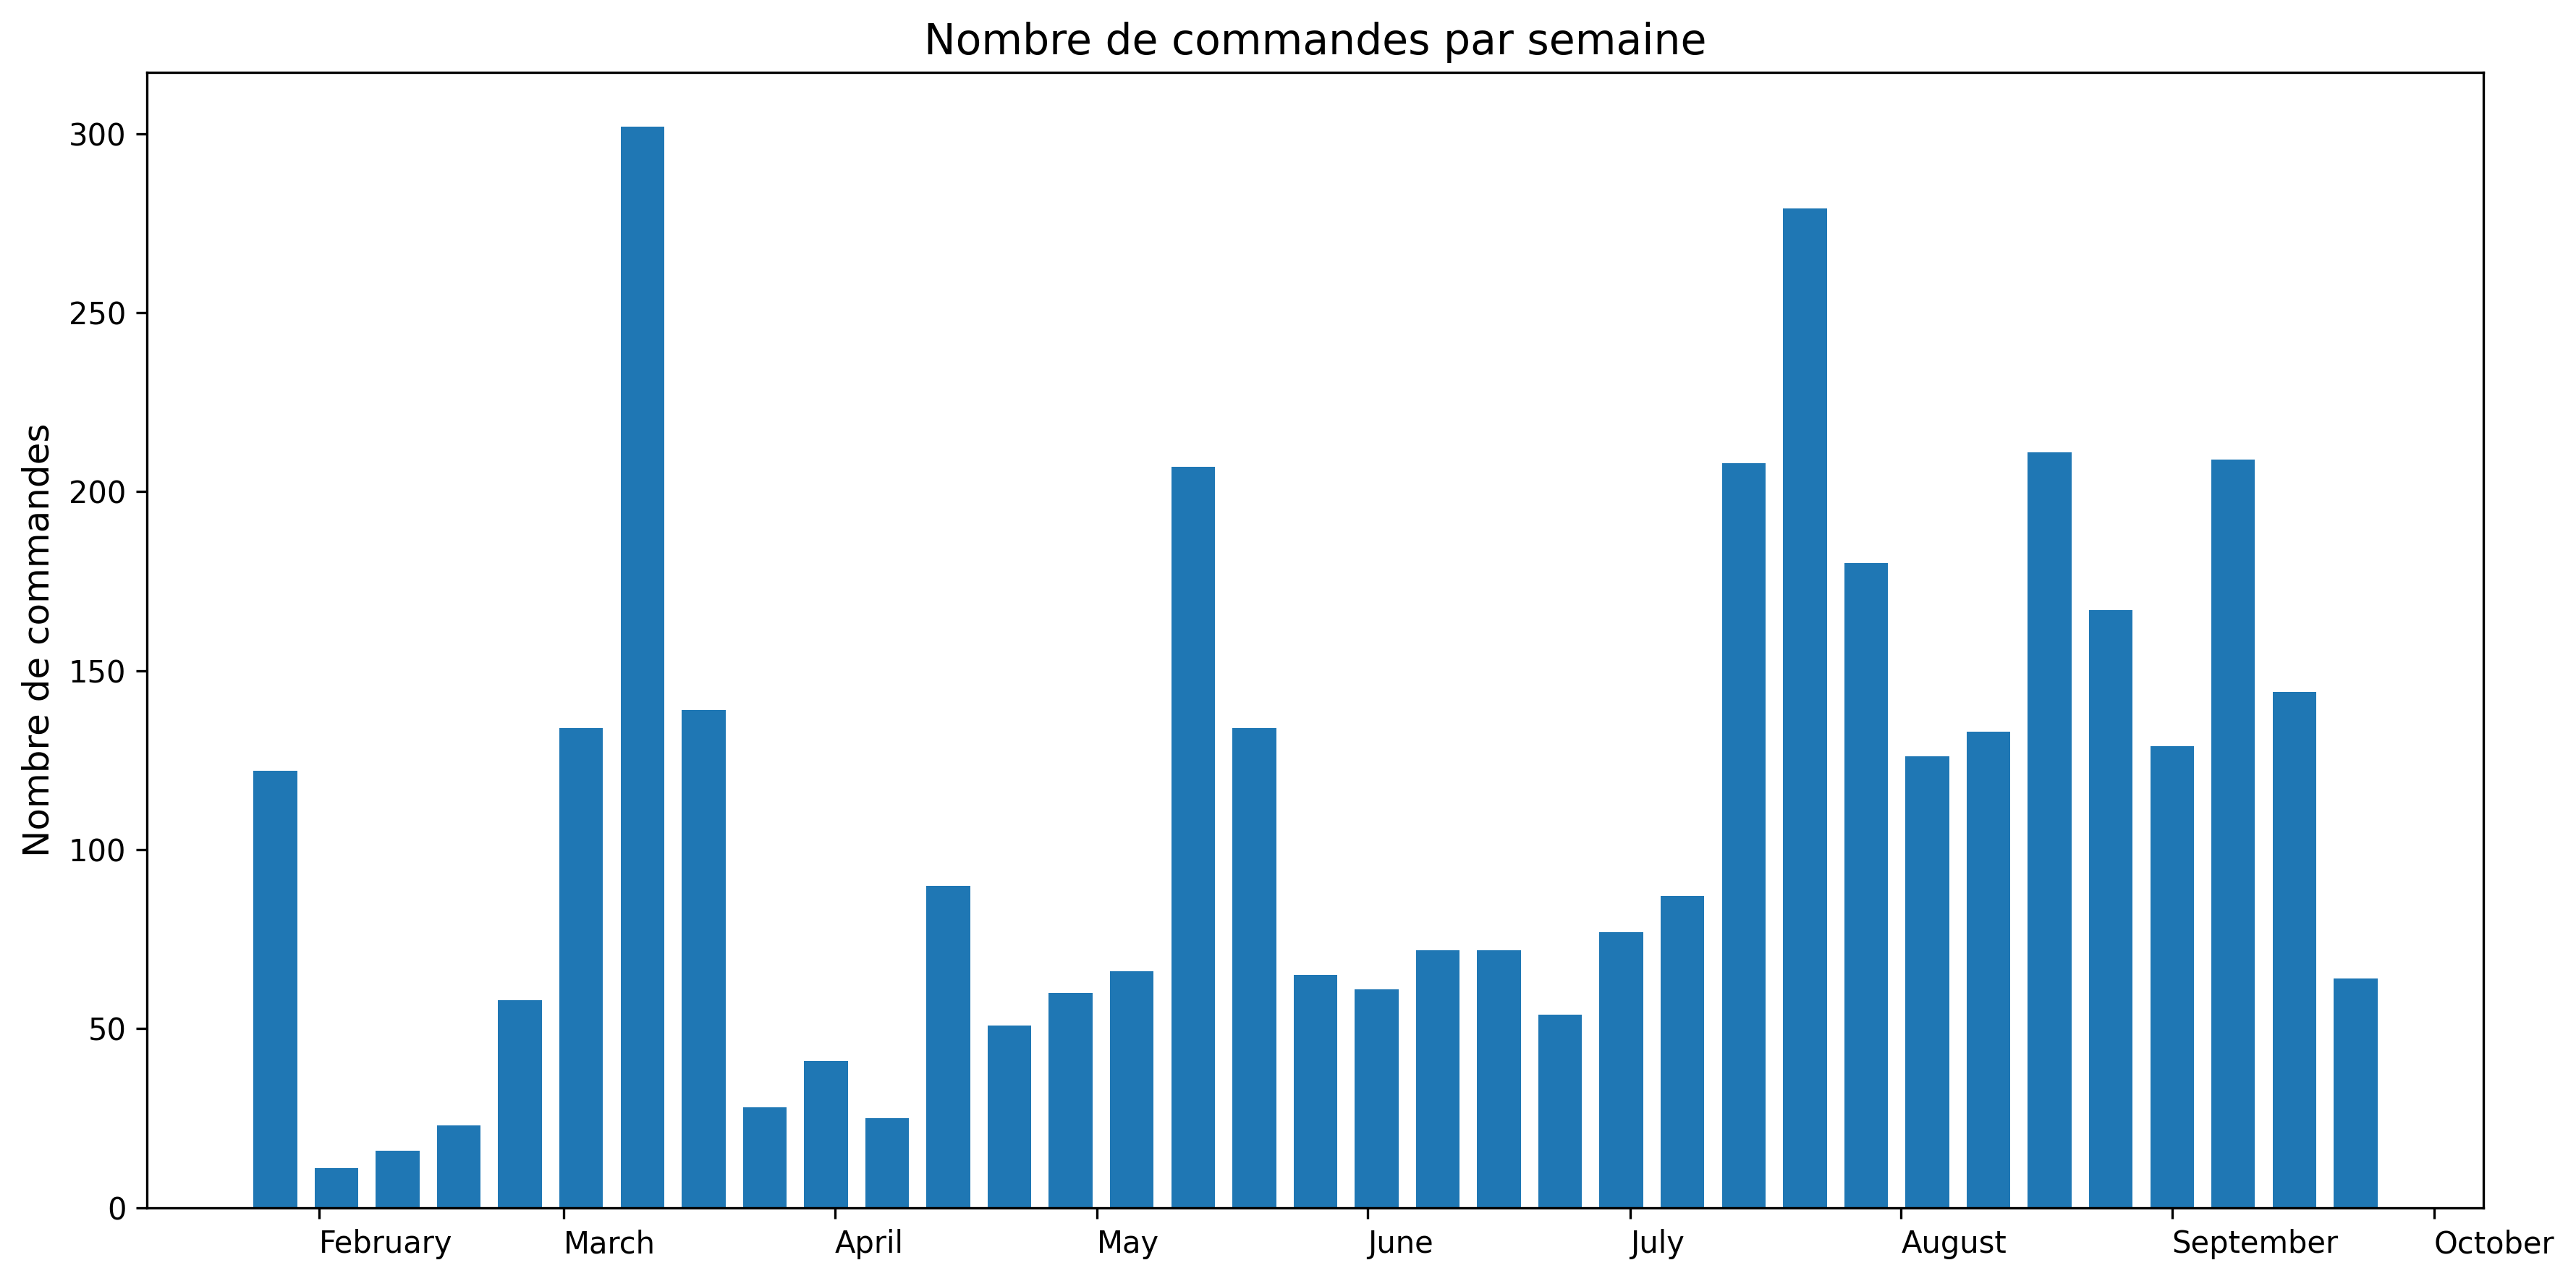

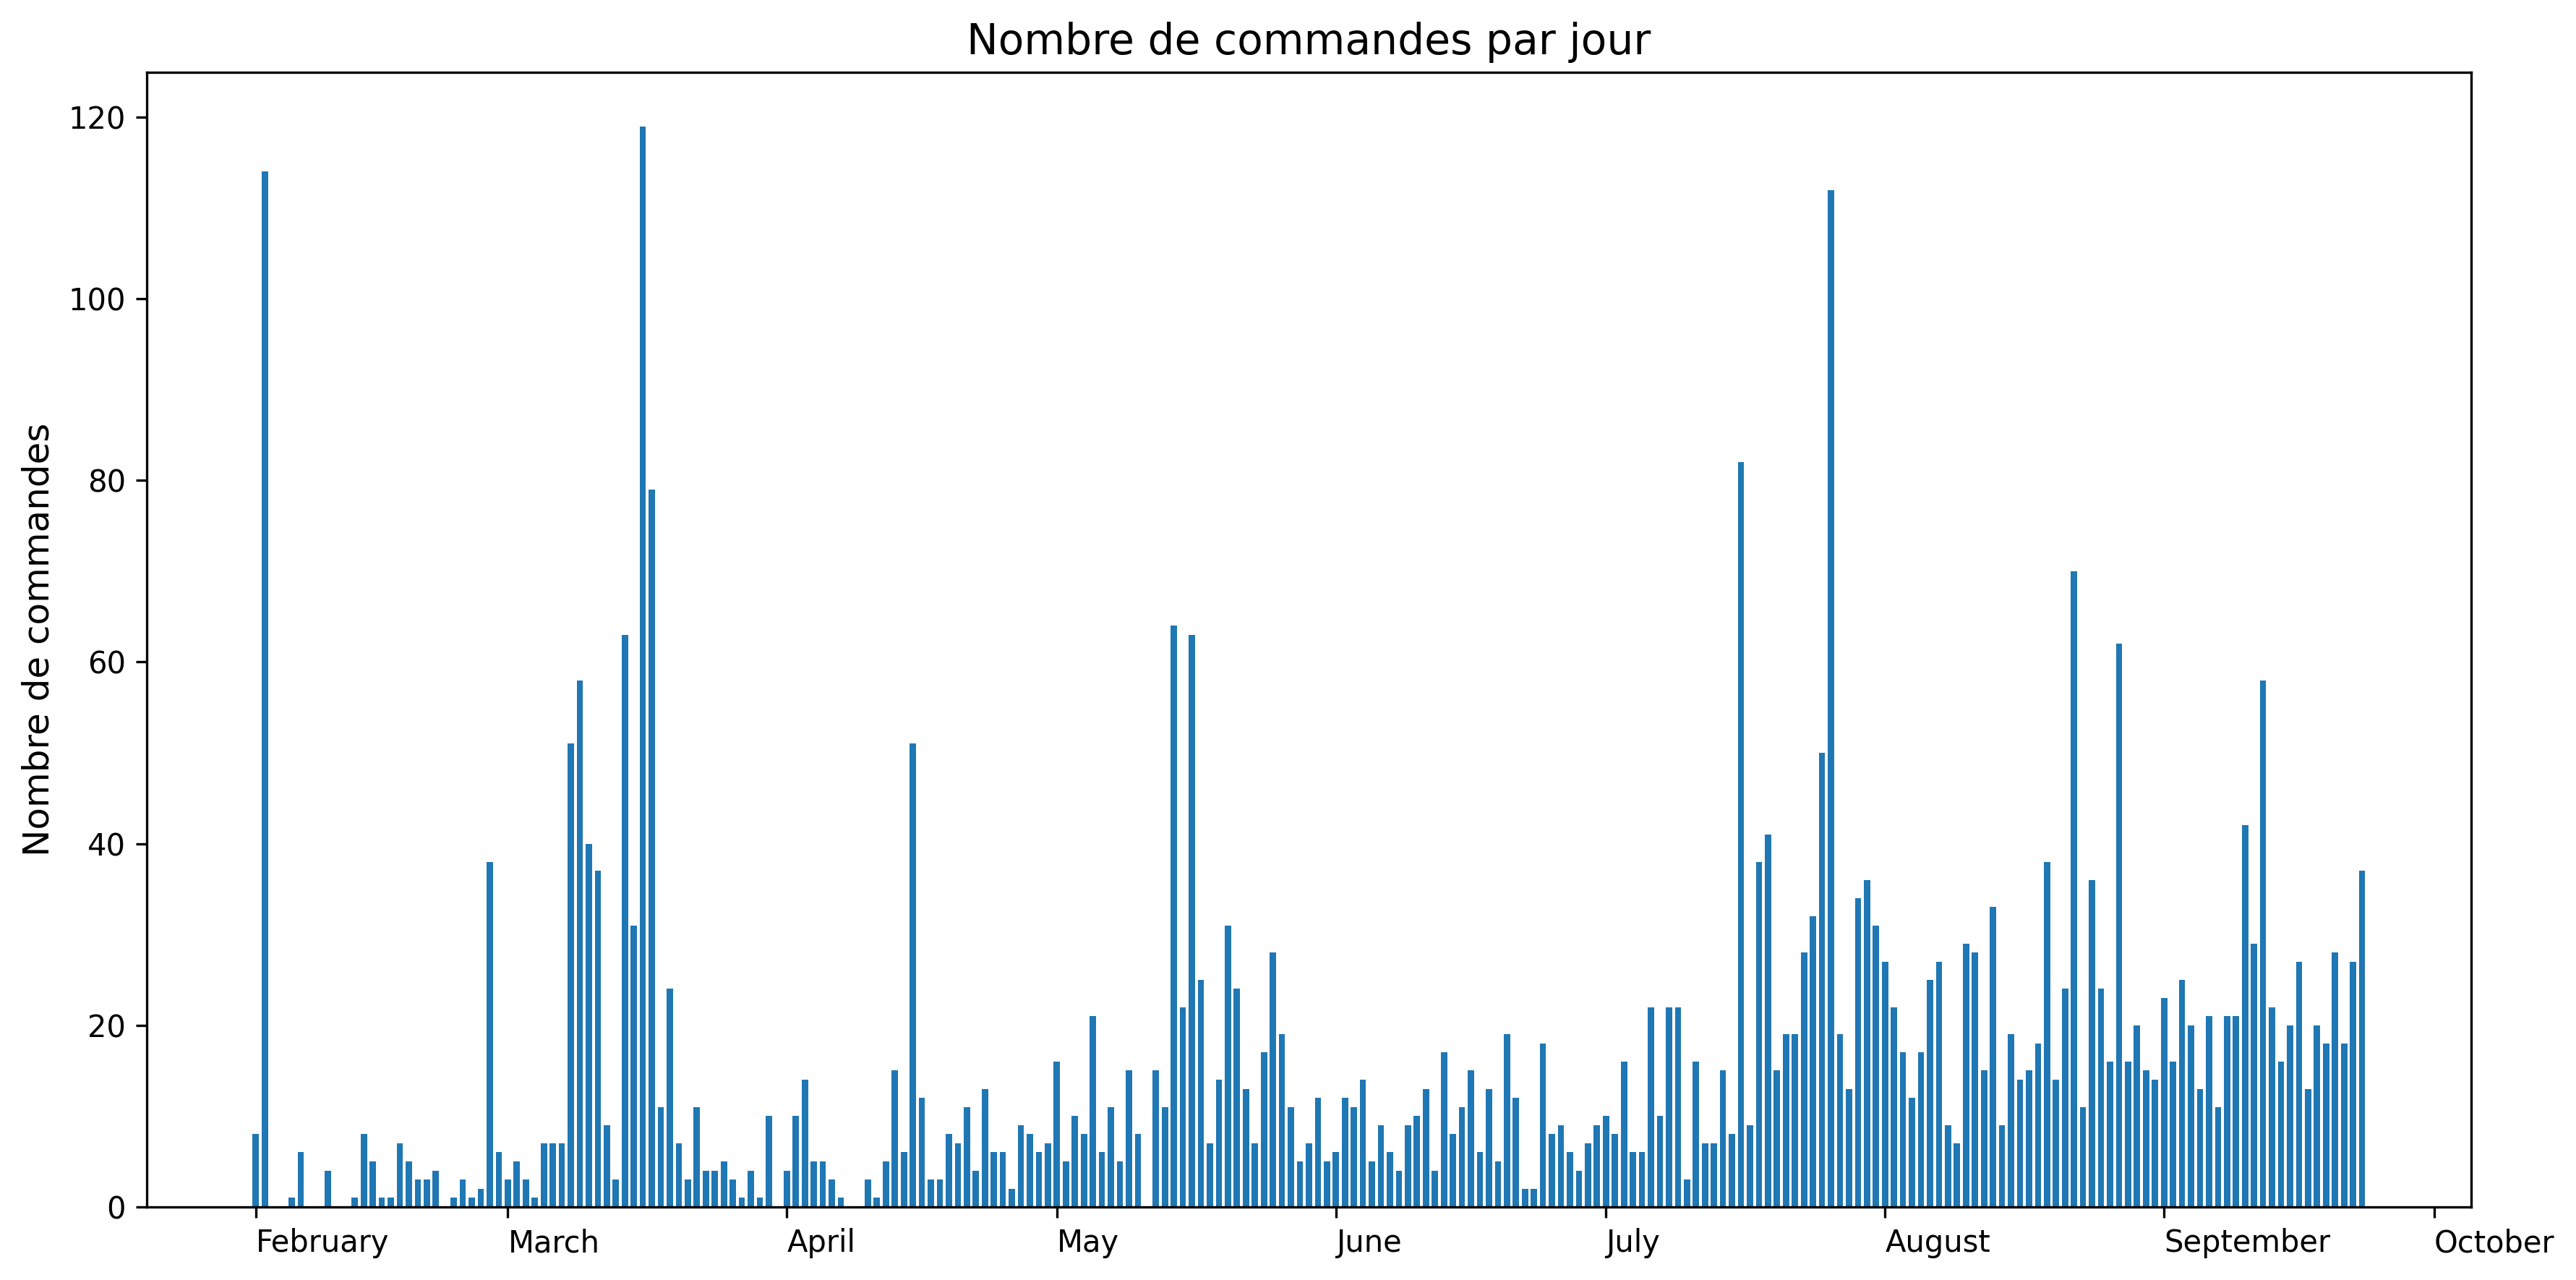

In [255]:

# Assurer que executed_at est bien un datetime
logs['executed_at'] = pd.to_datetime(logs['executed_at'])

# --- Par jour ---
logs_per_day = logs.groupby(logs['executed_at'].dt.date).size()

# --- Par semaine ---
logs['week'] = logs['executed_at'].dt.to_period('W')
logs_per_week = logs.groupby('week').size()

# --- Par mois ---
logs['month'] = logs['executed_at'].dt.to_period('M')
logs_per_month = logs.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)

# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()





## utilisation des commandes warp

C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\1793532722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_warp['executed_at'] = pd.to_datetime(logs_warp['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\1793532722.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_warp['week'] = logs_warp['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\1793532722.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-vers

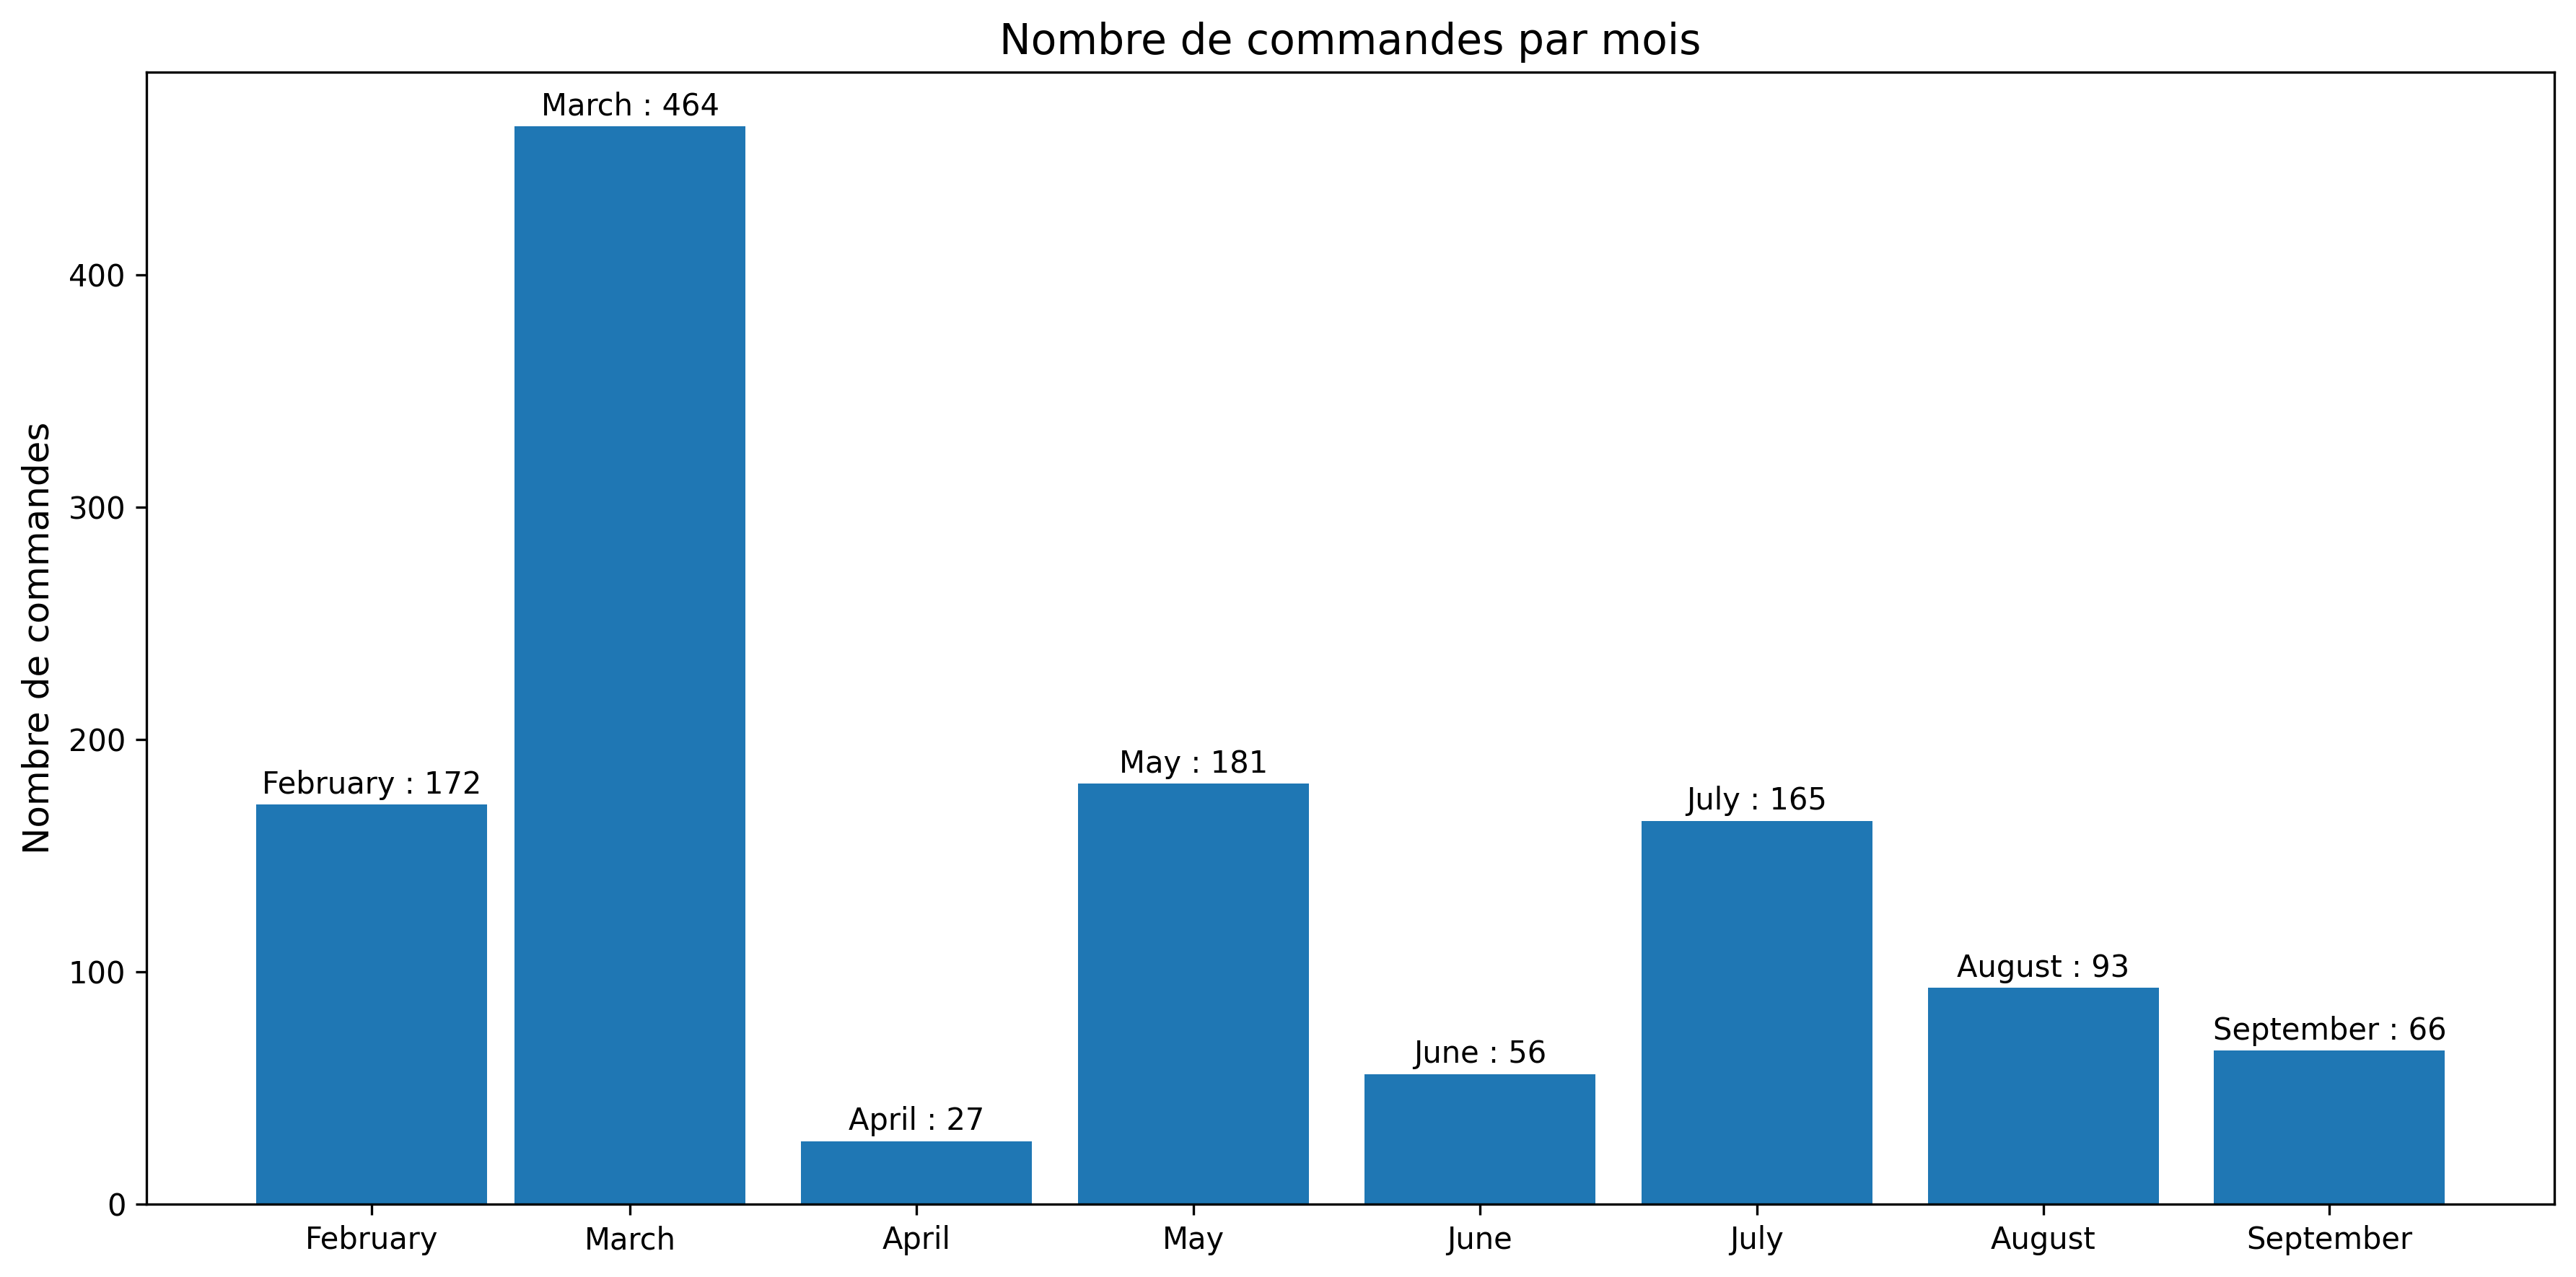

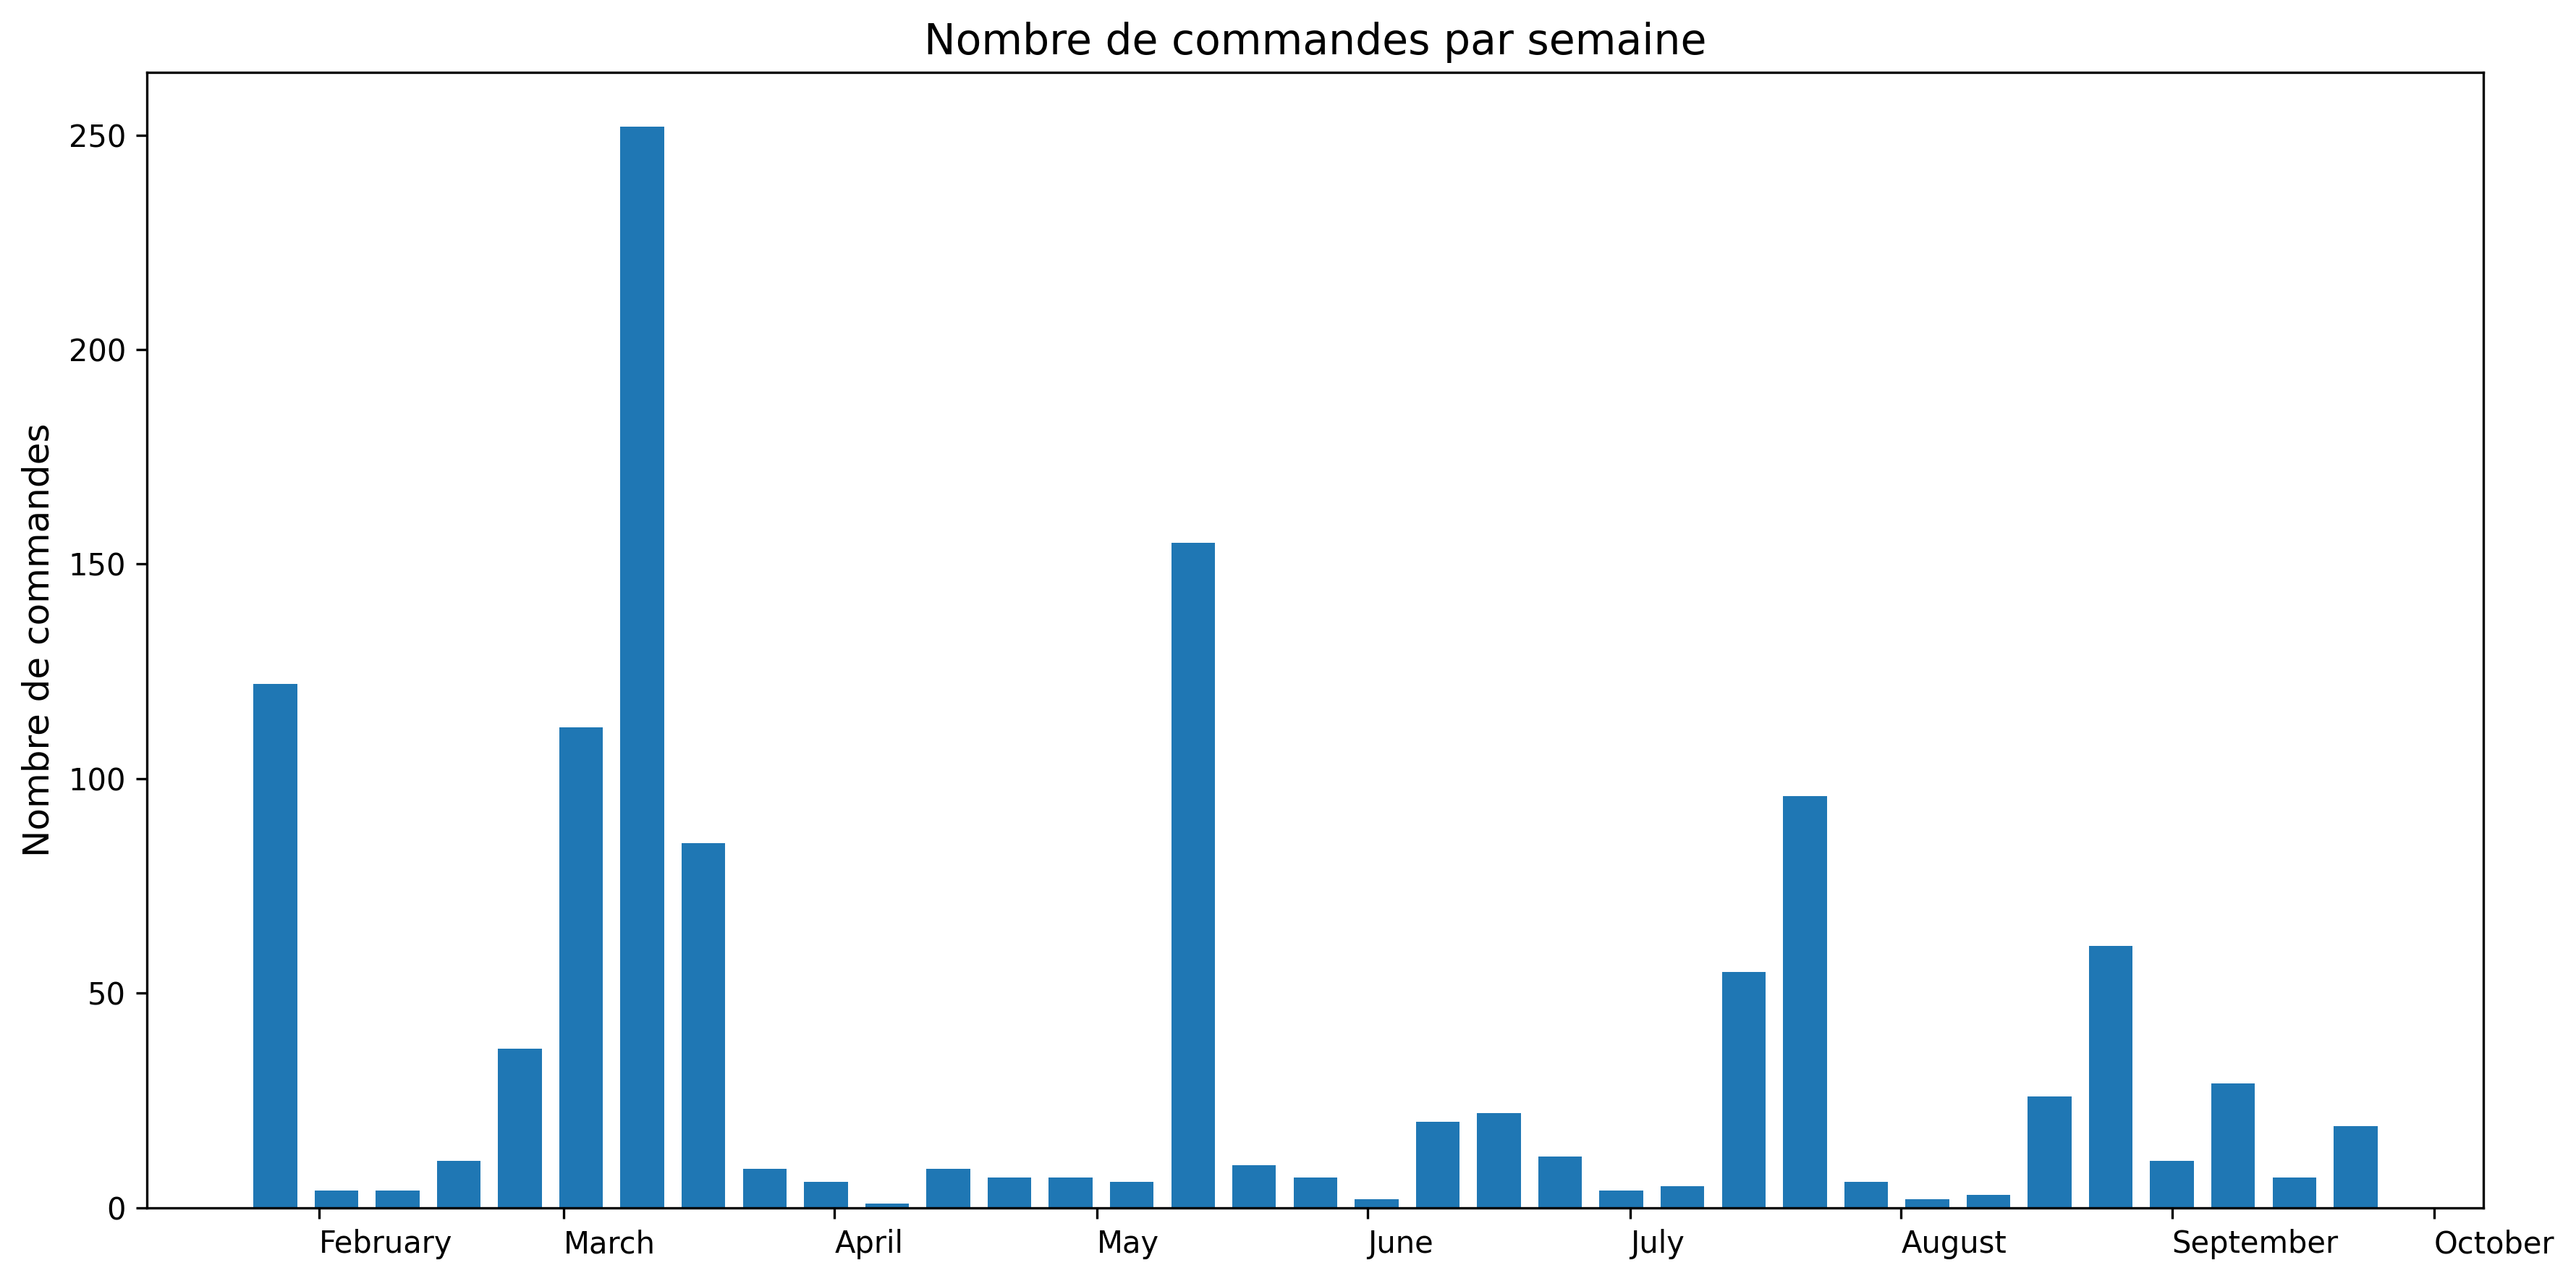

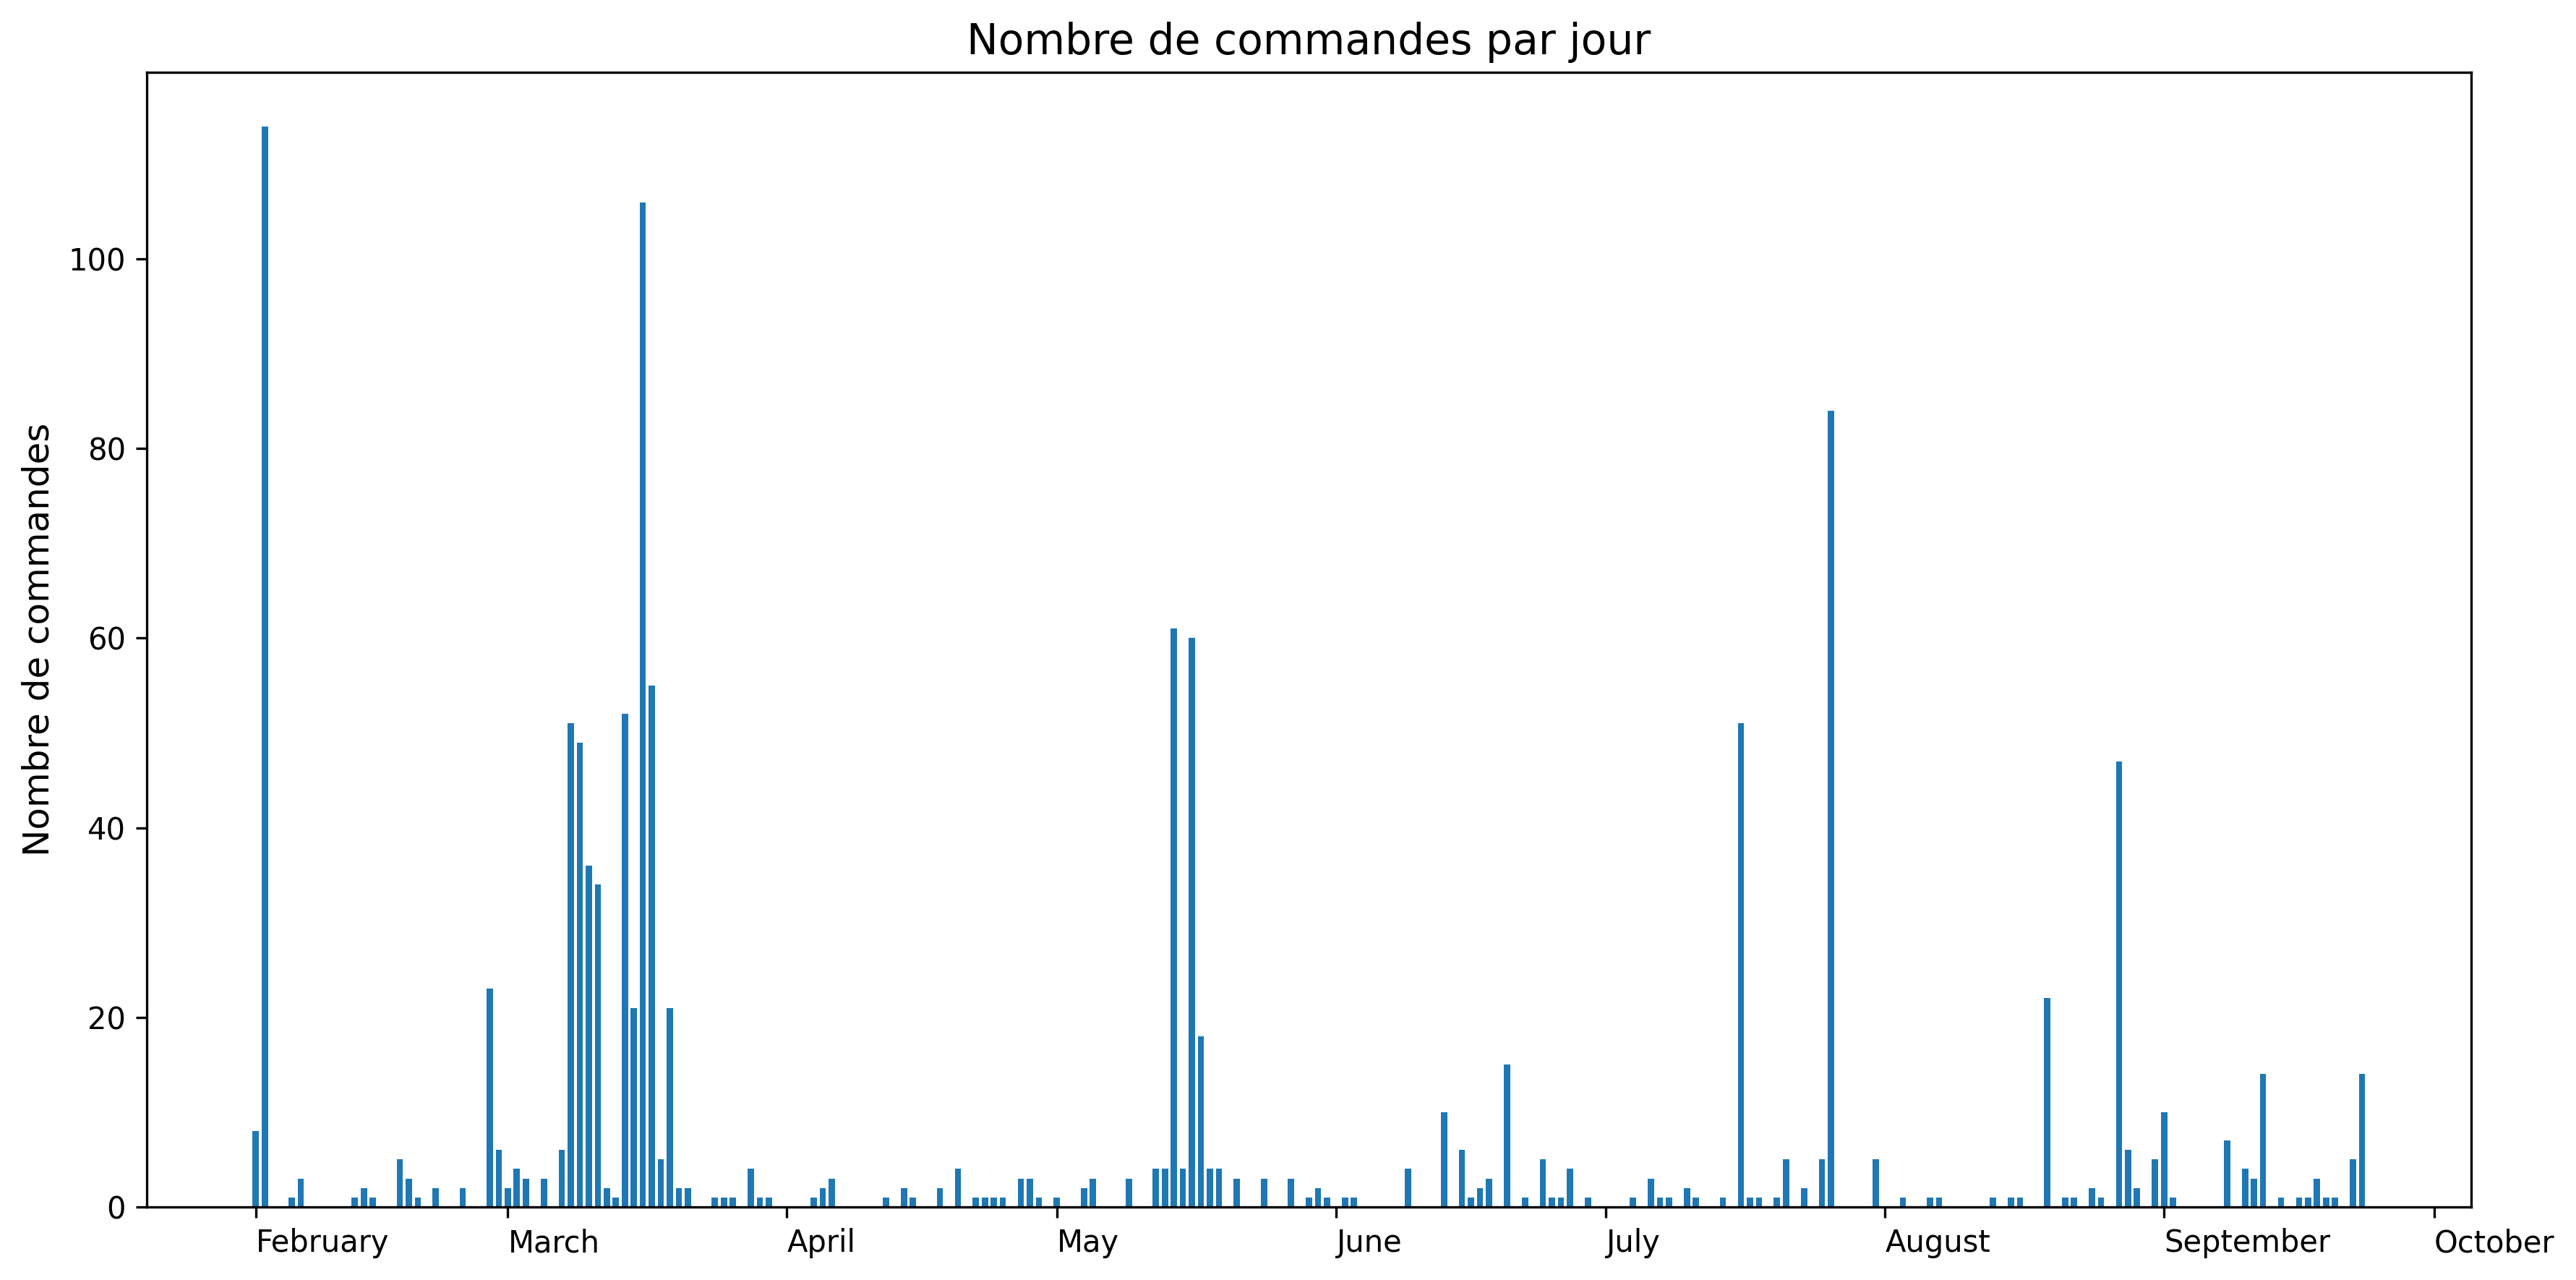

In [256]:

# Assurer que executed_at est bien un datetime
logs_warp['executed_at'] = pd.to_datetime(logs_warp['executed_at'])

# --- Par jour ---
logs_per_day = logs_warp.groupby(logs_warp['executed_at'].dt.date).size()

# --- Par semaine ---
logs_warp['week'] = logs_warp['executed_at'].dt.to_period('W')
logs_per_week = logs_warp.groupby('week').size()

# --- Par mois ---
logs_warp['month'] = logs_warp['executed_at'].dt.to_period('M')
logs_per_month = logs_warp.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)

# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()




# nombre de serveurs et utilisateurs ayant >10 commandes

In [257]:
logs_per_user = logs_users.groupby("user_name")["id"].count().sort_values(ascending=False)
print("nombre d'utilisateurs :",len(logs_per_user))
print("nombre d'utilisateurs ayant fait plus de 3 commandes :",len([logs_per_user.index[i] for i in range(len(logs_per_user)) if logs_per_user.iloc[i]>3]))
print("classement des plus gros utilisateurs du bot en nombre de commandes utilisées:")

rang=1
for usr in logs_per_user.iloc[:10].index:
    nb_cmd=logs_per_user[usr]
    print(f" - {rang}. @{usr} : {nb_cmd}")
    rang+=1
    

nombre d'utilisateurs : 444
nombre d'utilisateurs ayant fait plus de 3 commandes : 200
classement des plus gros utilisateurs du bot en nombre de commandes utilisées:
 - 1. @joao1784 : 68
 - 2. @.grybz : 65
 - 3. @klaudrr : 47
 - 4. @kymoh_ : 37
 - 5. @toonsi93_ : 35
 - 6. @cedp : 33
 - 7. @anyway3350 : 32
 - 8. @zabuzay : 27
 - 9. @_zikxo : 26
 - 10. @reda9665 : 25


In [258]:
logs_per_server = logs_users.groupby("guild_name")["id"].count().sort_values(ascending=False)
print("nombre de serveurs :",len(logs_per_server))
print("nombre de serveurs ayant fait plus de 3 commandes :",len([logs_per_server.index[i] for i in range(len(logs_per_server)) if logs_per_server.iloc[i]>3]))
print("classement des plus gros utilisateurs du bot en nombre de commandes utilisées:")

rang=1
for usr in logs_per_server.iloc[:10].index:
    nb_cmd=logs_per_server[usr]
    print(f" - {rang}. {usr} : {nb_cmd}")
    rang+=1

nombre de serveurs : 78
nombre de serveurs ayant fait plus de 3 commandes : 58
classement des plus gros utilisateurs du bot en nombre de commandes utilisées:
 - 1. La Secte : 387
 - 2. Dofus Touls : 346
 - 3. Origami : 174
 - 4. Stellar - Dofus TOUCH : 117
 - 5. Horizon : 110
 - 6. Maarss Community : 95
 - 7. H O N O R E D : 95
 - 8. The-Horde : 92
 - 9. Tchiki-tchiki : 82
 - 10. l Askip l : 70


# nombre d'utilisateurs/serveurs par mois

C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\2838007625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\2838007625.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(logs_users['executed_at'].dt.to_period('M'))['user_name']
C:\Users\Joannes\AppData\Local\Temp\ipykernel_20080\2838007625.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(logs_users['executed_at'].dt.to_period('M'))['guild_name']


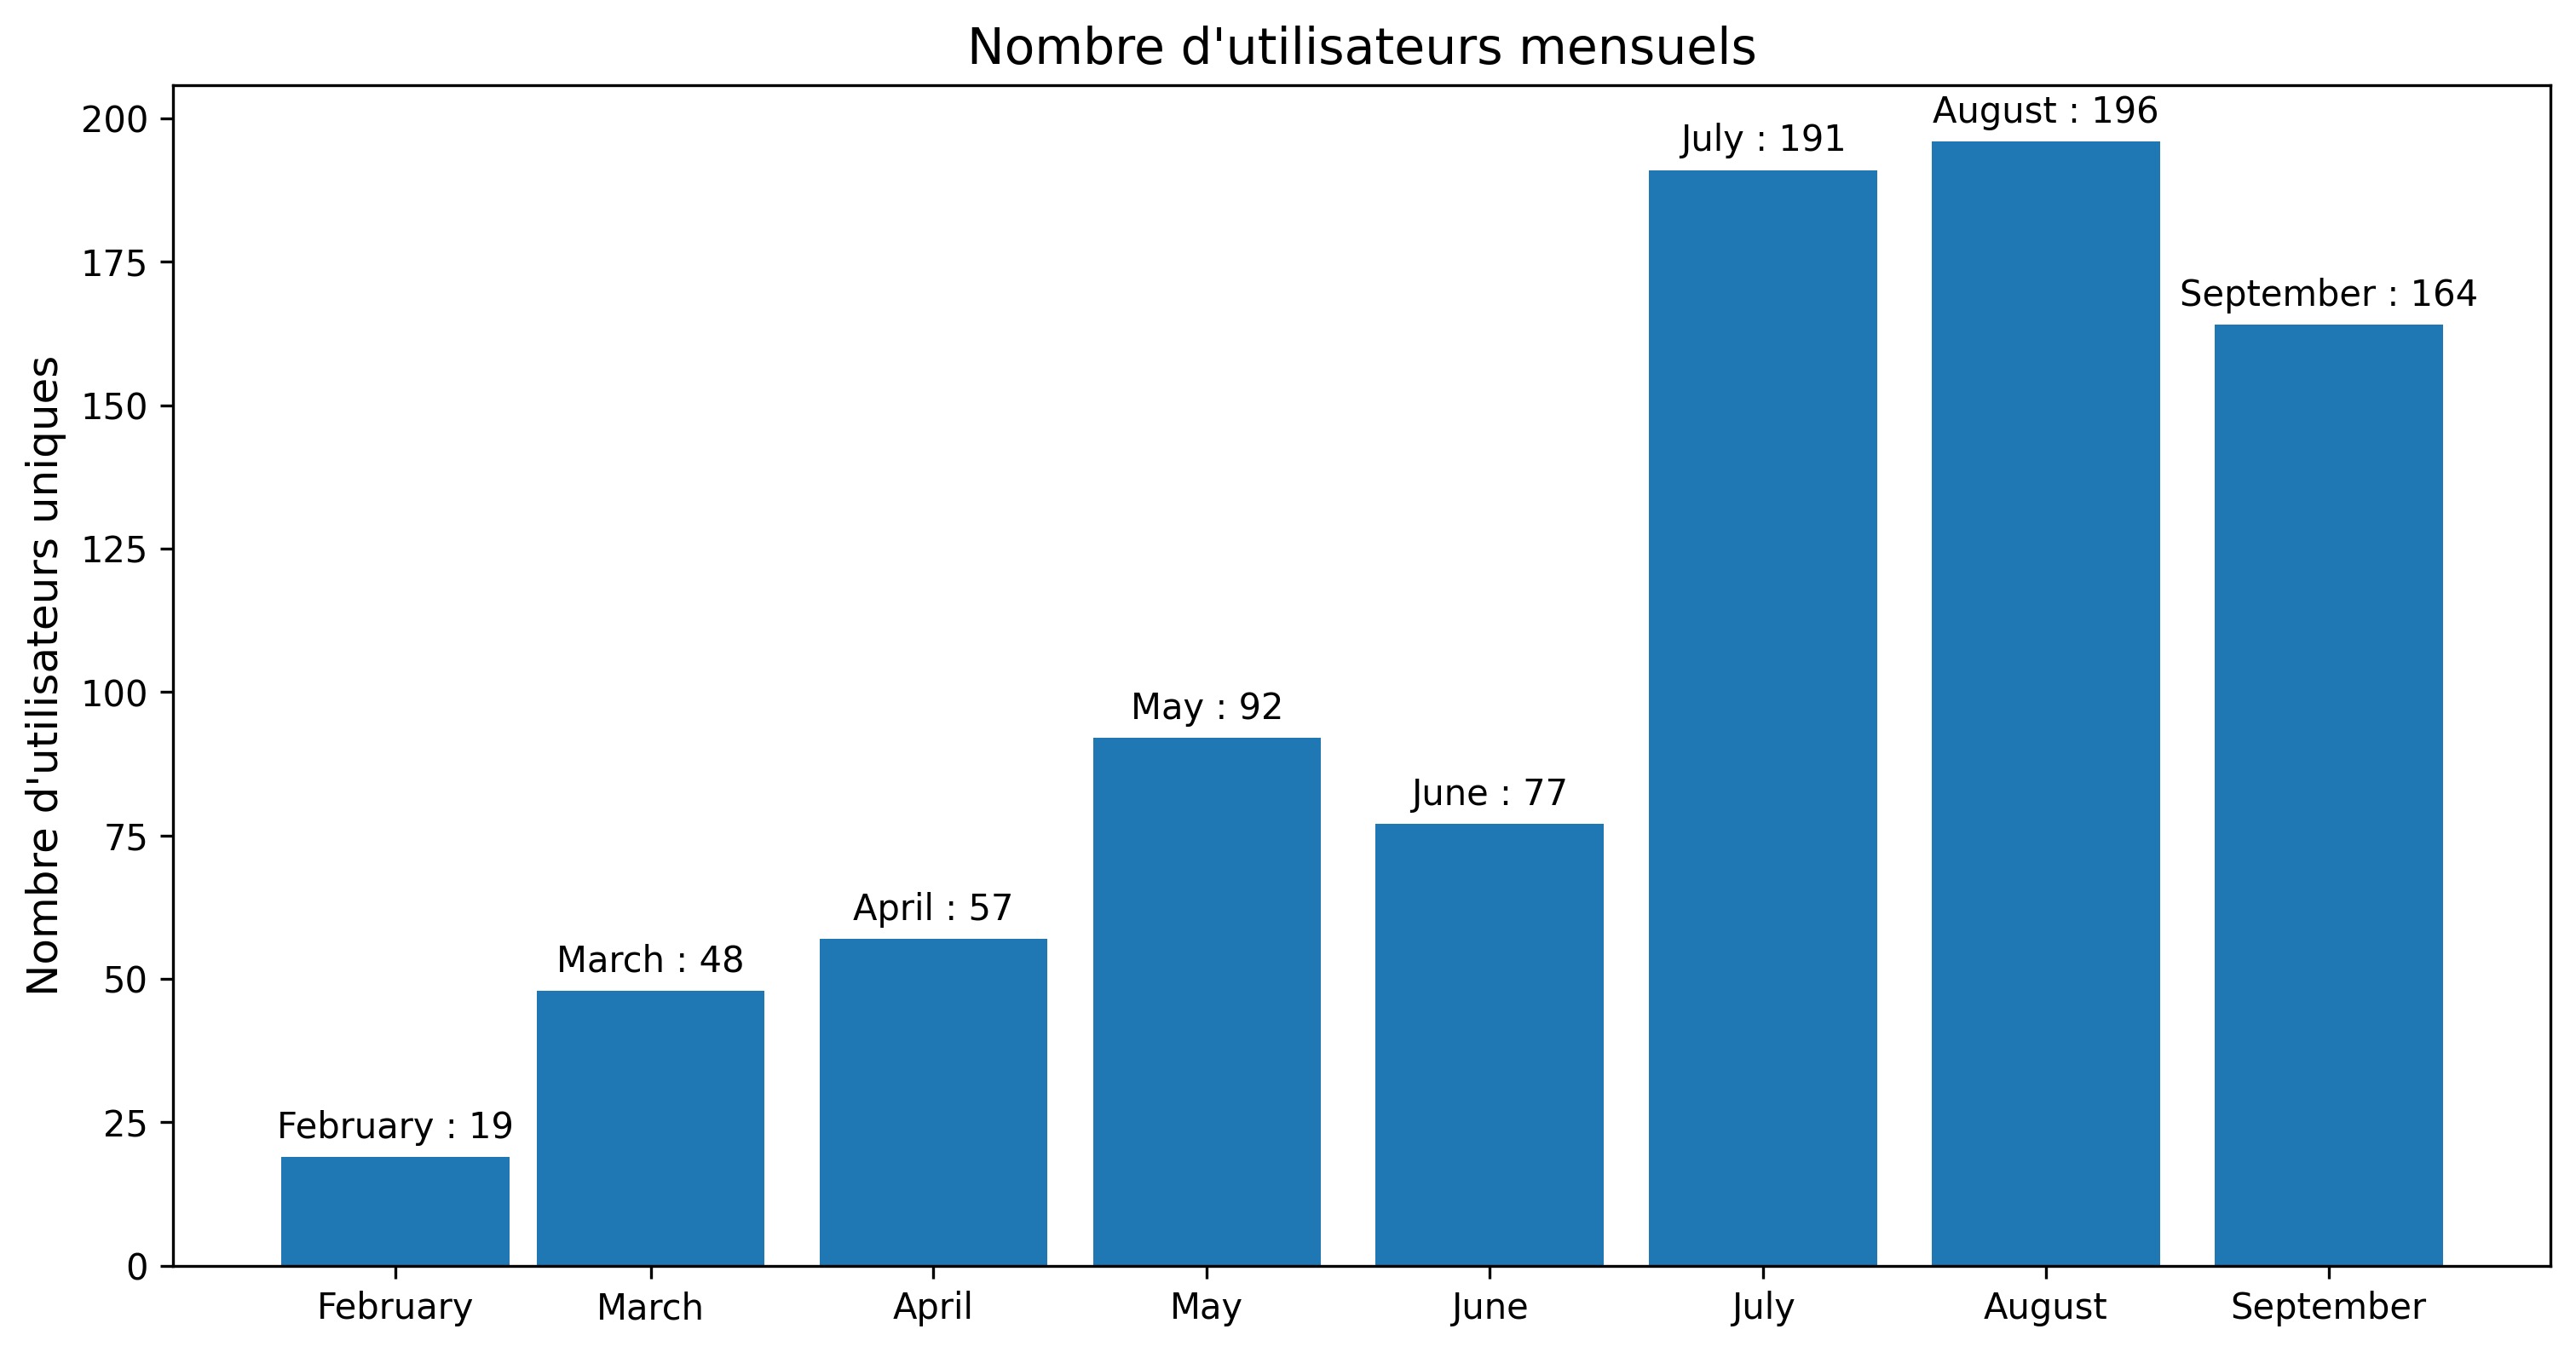

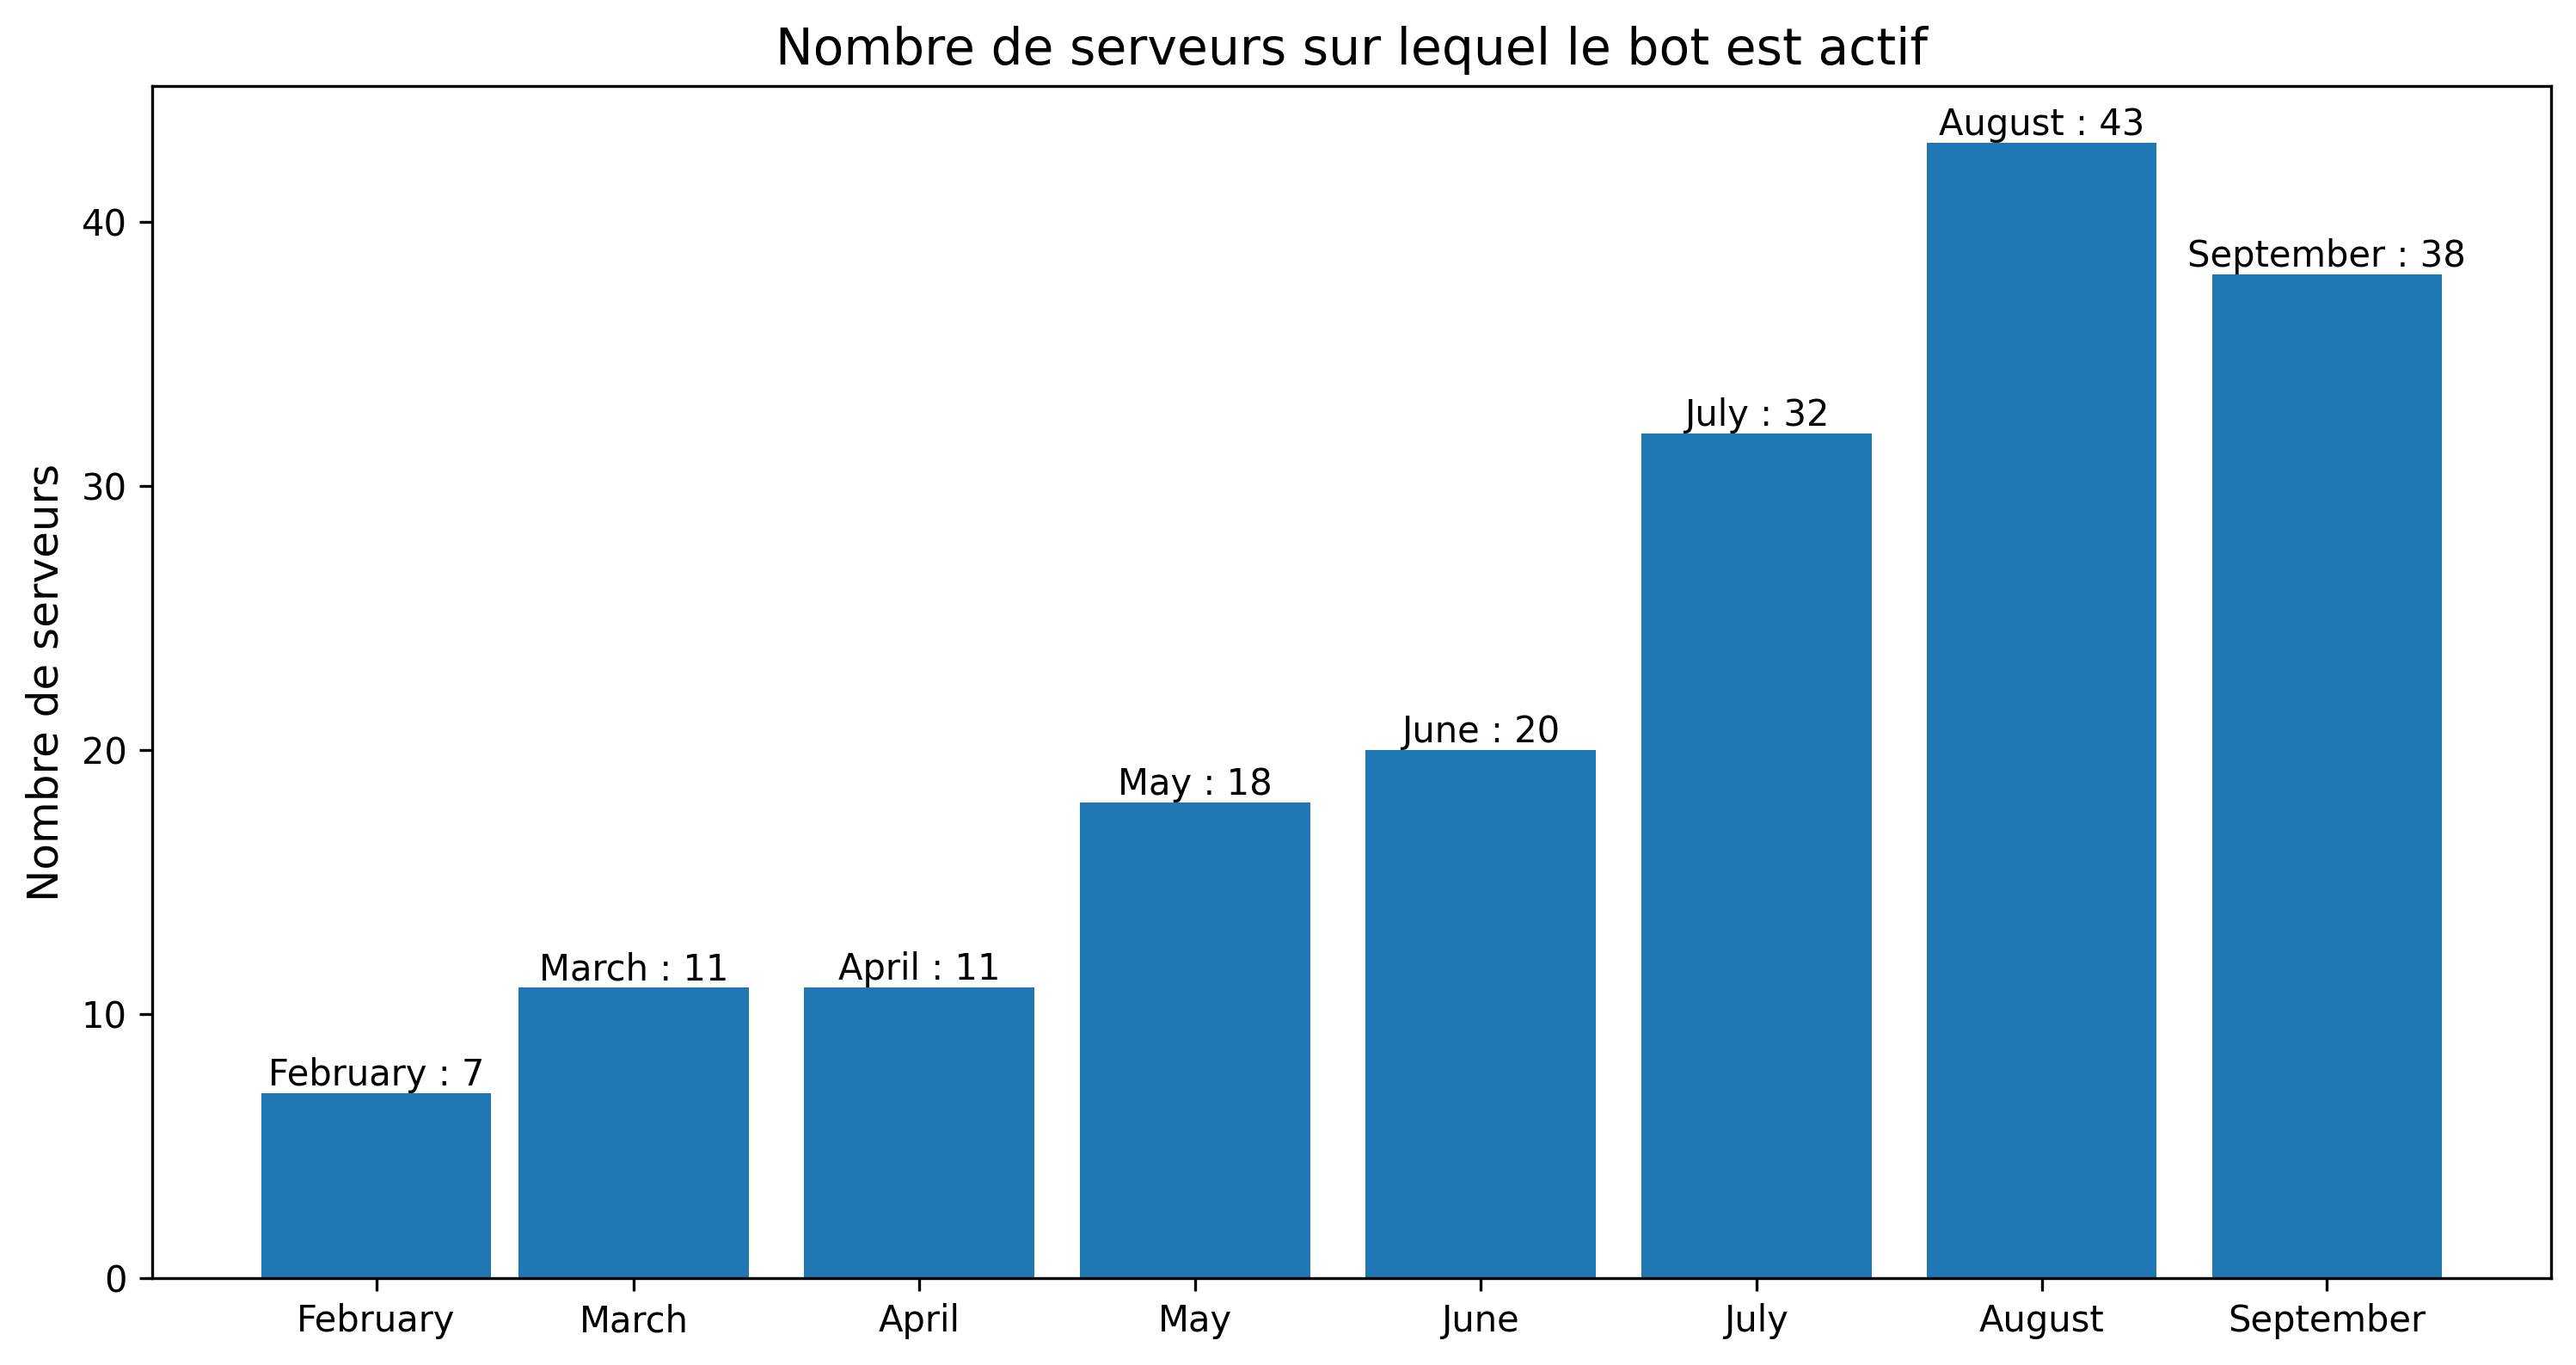

In [259]:
# S'assurer que executed_at est bien en datetime
logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])

# Grouper par mois et compter les utilisateurs uniques
unique_users_per_month = (
    logs_users
    .groupby(logs_users['executed_at'].dt.to_period('M'))['user_name']
    .nunique()
)
# Convertir l'index Period -> Timestamp pour l'affichage sur le graphique
unique_users_per_month.index = unique_users_per_month.index.to_timestamp()

# Grouper par mois et compter les serveurs uniques
unique_guilds_per_month = (
    logs_users
    .groupby(logs_users['executed_at'].dt.to_period('M'))['guild_name']
    .nunique()
)
# Convertir l'index Period -> Timestamp pour l'affichage sur le graphique
unique_guilds_per_month.index = unique_guilds_per_month.index.to_timestamp()
# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)



# --- Par mois ---
if not isinstance(unique_users_per_month.index, pd.DatetimeIndex):
    unique_users_per_month.index = unique_users_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(unique_users_per_month.index, unique_users_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre d'utilisateurs mensuels", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre d'utilisateurs uniques", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(unique_users_per_month)):
    ax.text(
        unique_users_per_month.index[i],               # X = la vraie date
        unique_users_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{unique_users_per_month.index[i].strftime('%B')} : {unique_users_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )


# --- Par mois ---
if not isinstance(unique_guilds_per_month.index, pd.DatetimeIndex):
    unique_guilds_per_month.index = unique_guilds_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(unique_guilds_per_month.index, unique_guilds_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de serveurs sur lequel le bot est actif", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de serveurs", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(unique_guilds_per_month)):
    ax.text(
        unique_guilds_per_month.index[i],               # X = la vraie date
        unique_guilds_per_month.iloc[i],                # Y = hauteur de la barre
        f"{unique_guilds_per_month.index[i].strftime('%B')} : {unique_guilds_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

# arguments les plus utilisés

In [286]:
# top 10 des éléments, classement des classes

logs["arguments_dict"] = logs["arguments"].apply(
    lambda x: json.loads(x) if pd.notnull(x) else {}
)
logs["classe"] = logs["arguments_dict"].apply(lambda d: d.get("classe")).str.lower()
logs["element"] = logs["arguments_dict"].apply(lambda d: d.get("element")).str.lower()

classe_counts = logs["classe"].value_counts(dropna=True)
classe_counts_filtered = classe_counts[classe_counts > 10]
print(classe_counts_filtered)
element_counts = logs["element"].value_counts(dropna=True)
element_counts_filtered = element_counts[element_counts > 10]
print(element_counts_filtered)


classe
ecaflip     208
zobal       121
sacrieur    115
sadida      113
enutrof     112
pandawa     112
cra         112
eniripsa    111
iop         103
steamer     102
feca         96
osamodas     93
sram         91
xelor        80
roublard     72
Name: count, dtype: int64
element
terre                              462
eau                                233
feu                                230
air                                210
dopou                              167
cc                                  43
terre eau                           41
feu eau                             38
do pou                              37
eau air                             37
terre feu                           35
terre cc                            28
soin                                27
eau feu                             25
multi                               24
pp                                  22
terre air                           20
feu air                             20
air feu          

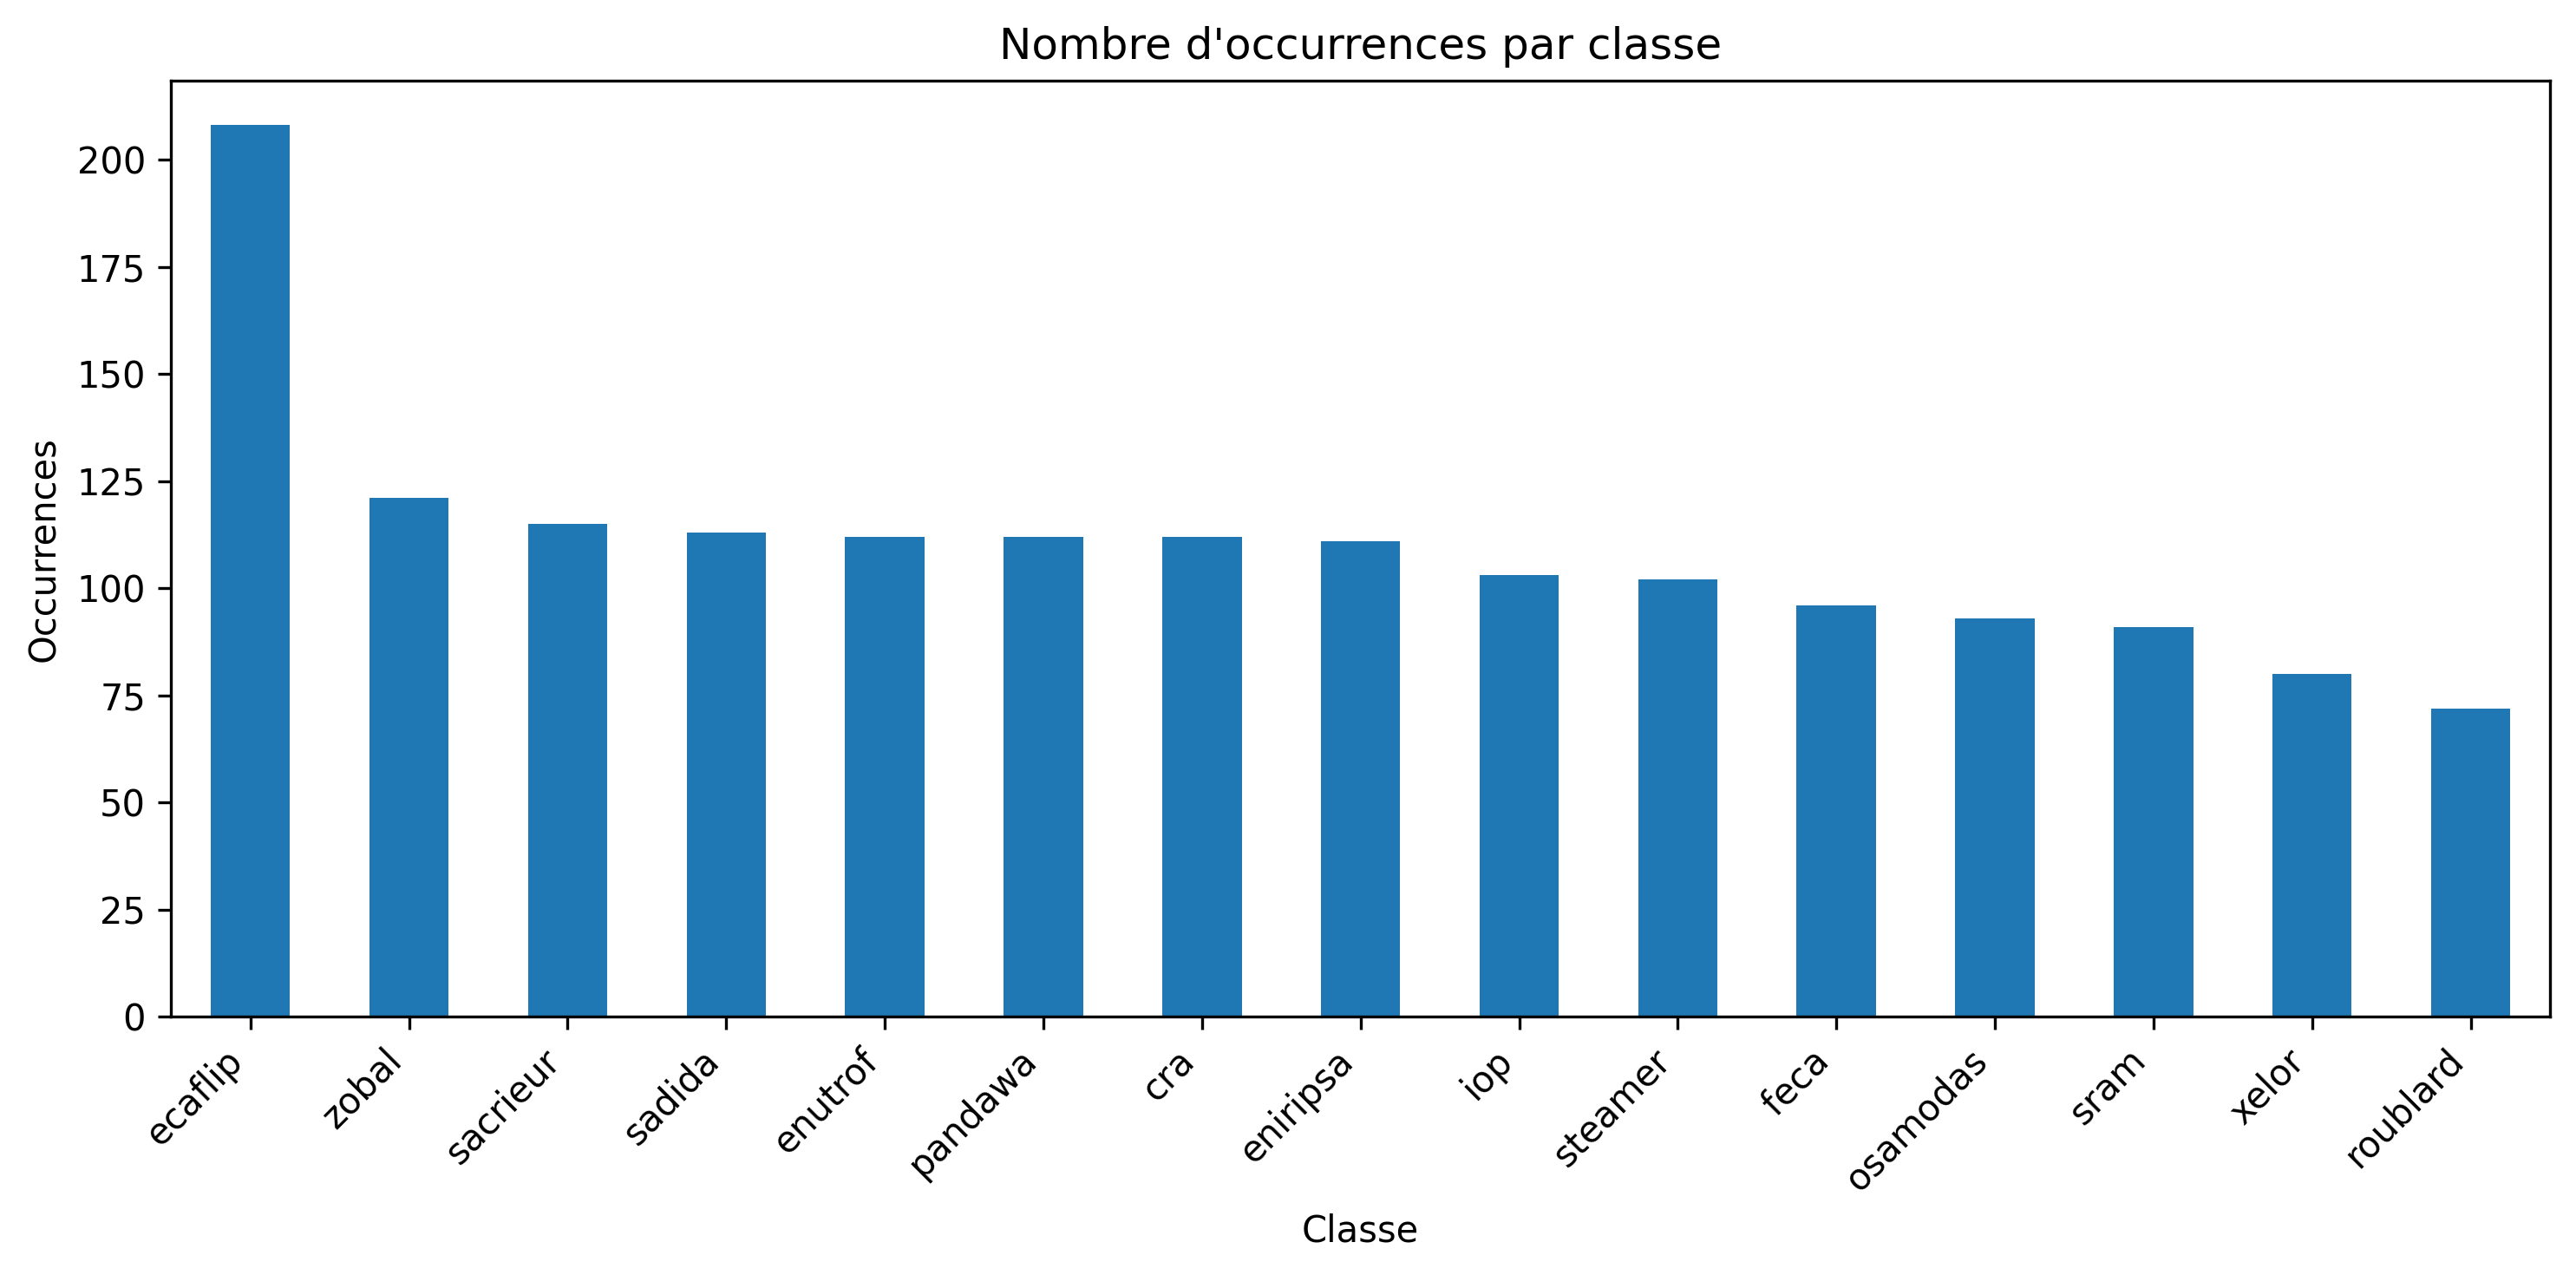

In [288]:
plt.figure(figsize=(10,5), dpi=300)
classe_counts_filtered.plot(kind='bar')
plt.title("Nombre d'occurrences par classe")
plt.xlabel("Classe")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


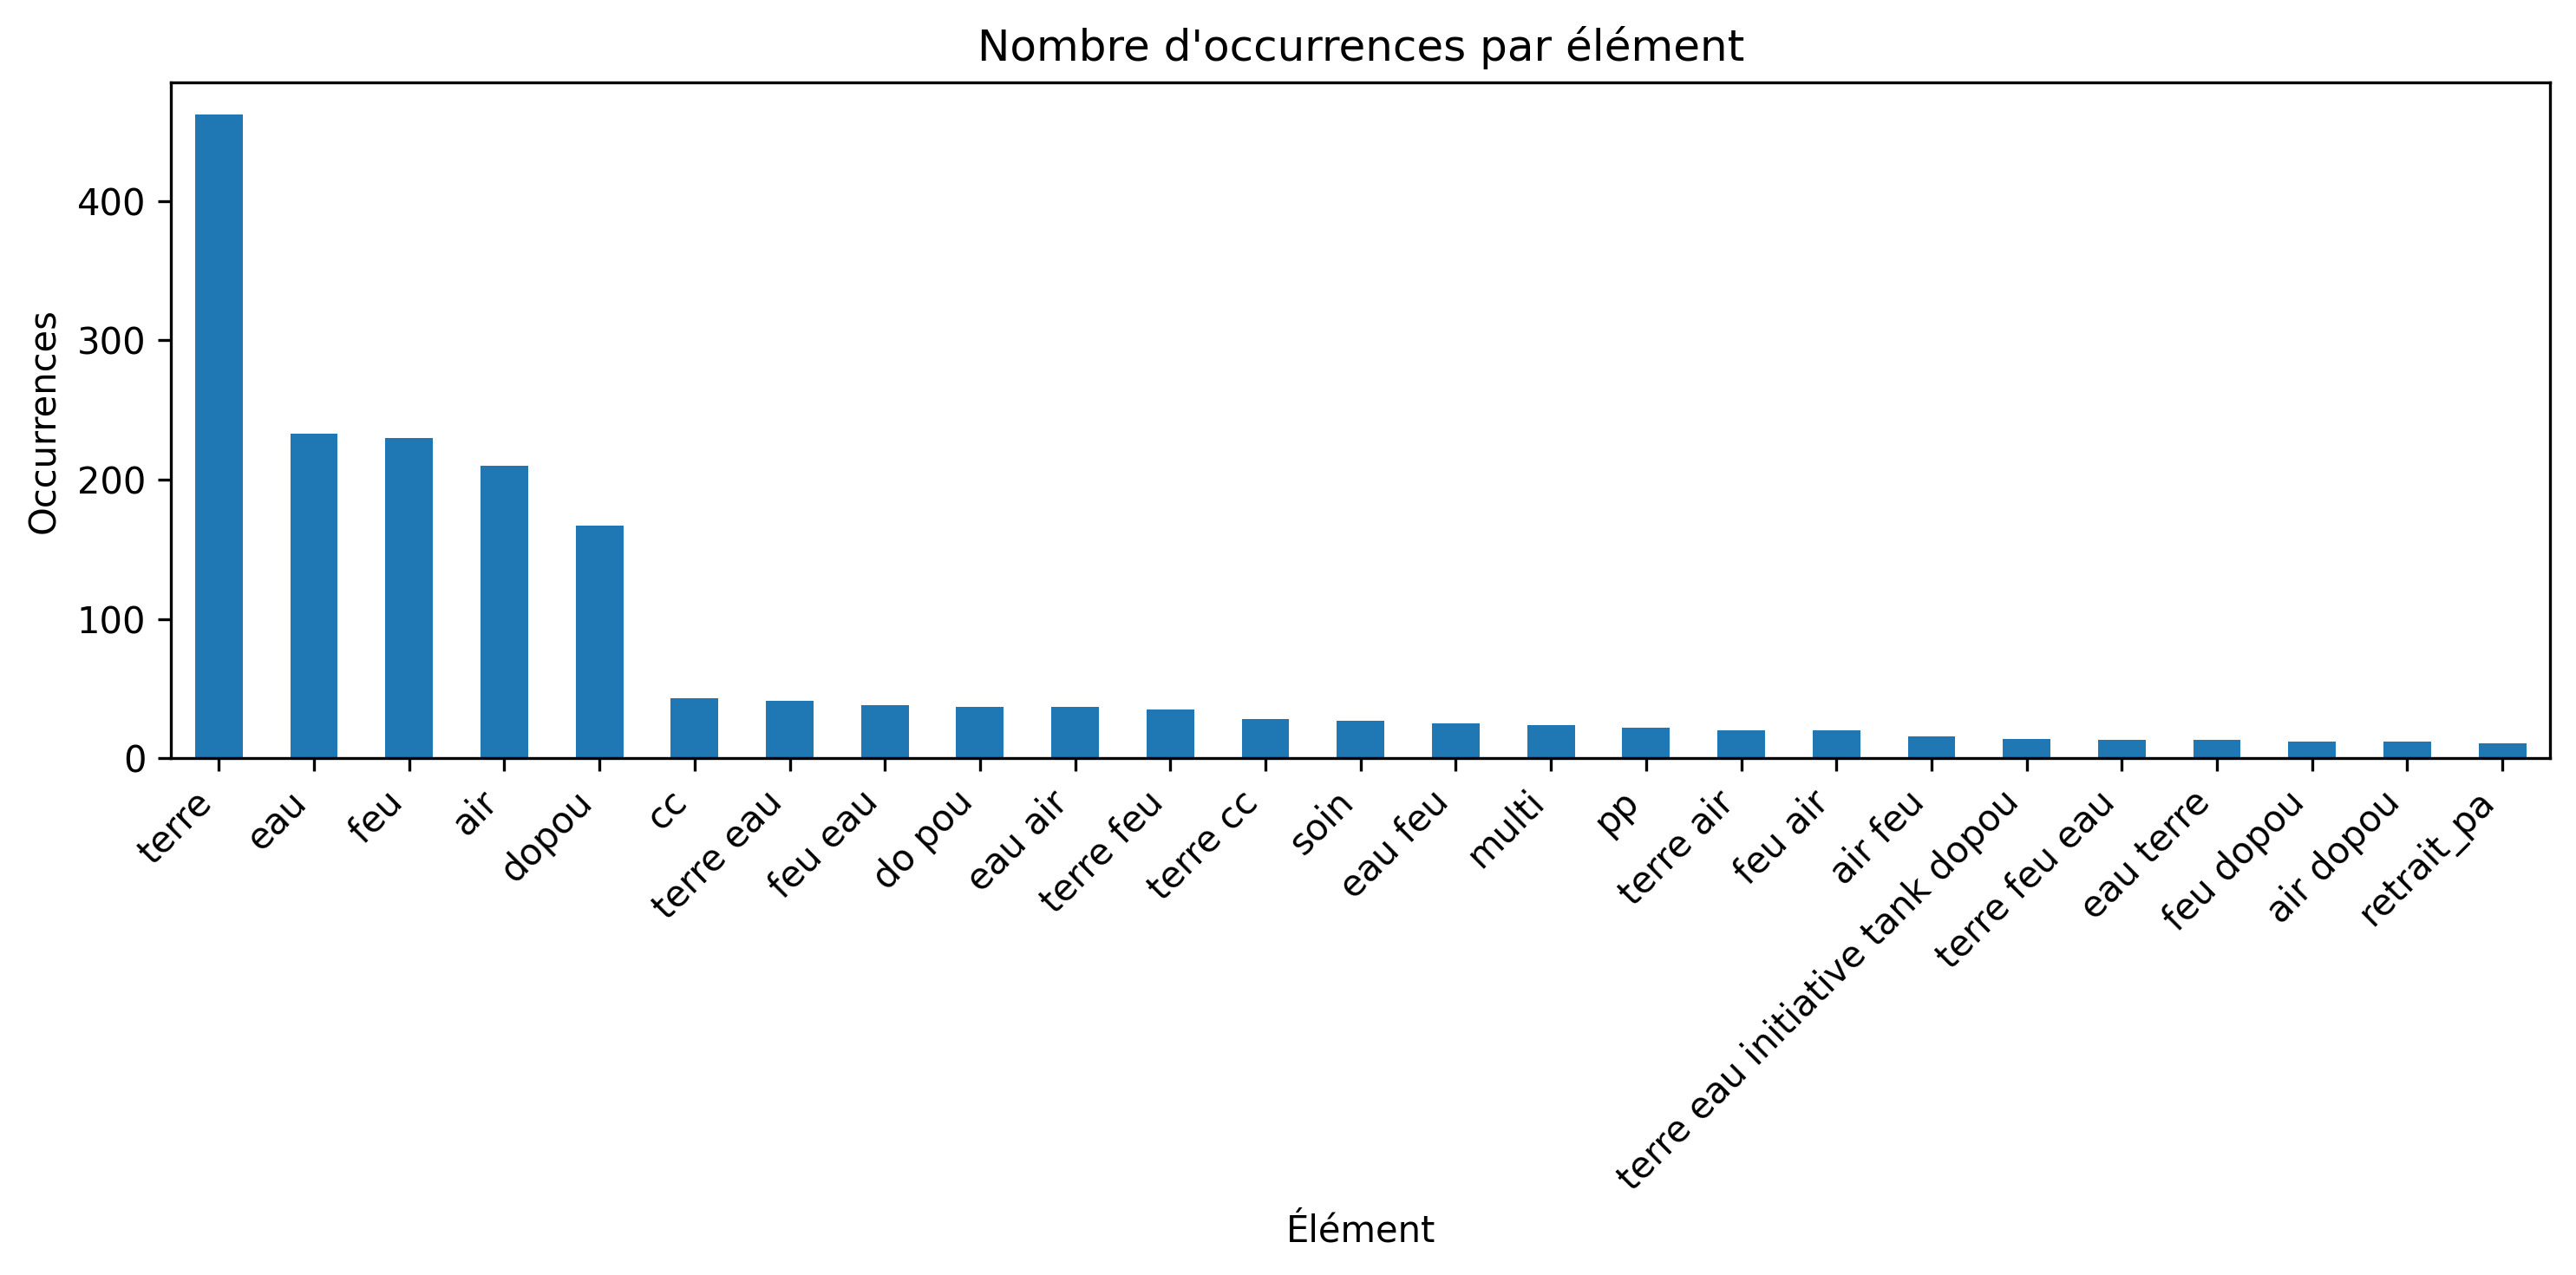

In [ ]:
plt.figure(figsize=(10,5), dpi=300)
element_counts_filtered.plot(kind='bar')
plt.title("Nombre d'occurrences par élément")
plt.xlabel("Élément")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#fun car do pou ne marche pas mais y'a énormément de gens qui font l'erreur
